Data directory : C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021\data\shapefiles
Output directory: C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021\data\outputs
CRS            : EPSG:31982

  2001.shp  →  OK
  2006.shp  →  OK
  2011.shp  →  OK
  2016.shp  →  OK
  2021.shp  →  OK
Class mapping:
  gridcode  3  →  Forest
  gridcode  6  →  Floodplain
  gridcode 11  →  Flooded Field
  gridcode 12  →  Natural Field
  gridcode 15  →  Pasture
  gridcode 24  →  Urban Area
  gridcode 33  →  Water
  gridcode 41  →  Temporary Crop

Reading shapefiles...
  2001  →  8 classes  |  total: 431,370.00 ha
  2006  →  8 classes  |  total: 431,368.22 ha
  2011  →  8 classes  |  total: 431,368.24 ha
  2016  →  8 classes  |  total: 431,368.20 ha
  2021  →  8 classes  |  total: 431,357.12 ha
Done.

Master DataFrame — hectares:
class_name     Forest  Floodplain  Flooded Field  Natural Field    Pasture  Urban Area     Water  Temporary Crop
Year                            

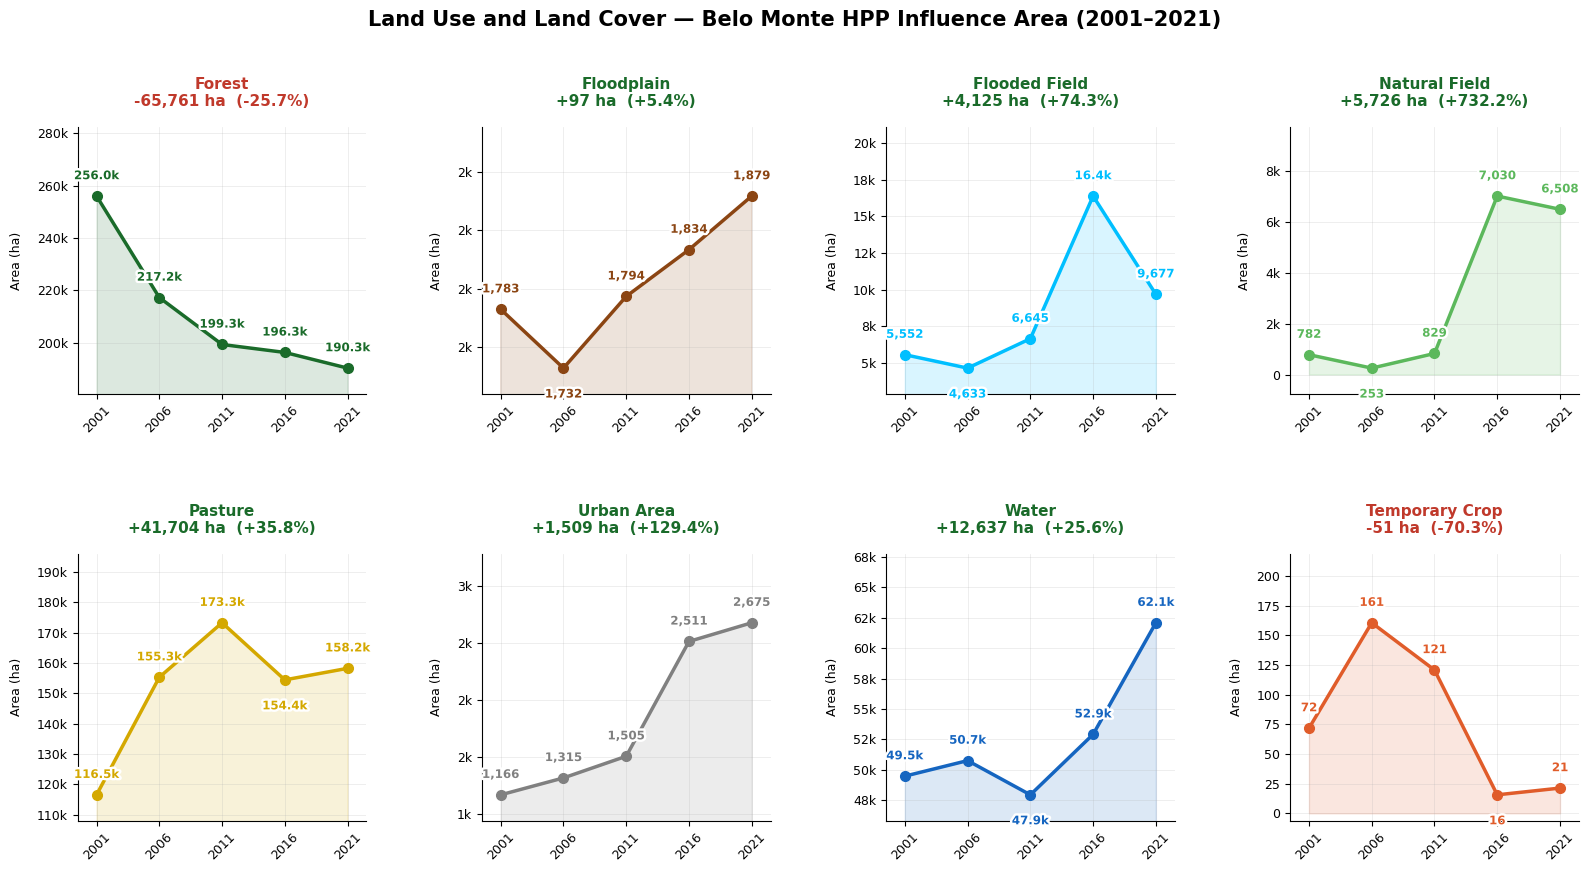

Figure saved: block01_lulcc_trajectories.png

BLOCK 01 COMPLETE

Variables available for subsequent blocks:
  df_ha
  df_pct
  YEARS
  CLASS_ORDER
  COLORS
  CRS_PROJ
  OUT_DIR
  DATA_DIR
  phases


In [3]:
# =============================================================================
# BLOCK 01 — DATA LOADING AND AREA CALCULATION
# Belo Monte HPP — Land Use and Land Cover Change (2001–2021)
# =============================================================================
#
# Description:
#   Reads classified land cover shapefiles for each epoch, reprojects to
#   SIRGAS 2000 UTM Zone 22S (EPSG:31982), computes geometric areas in
#   hectares, and assembles the master area DataFrames used by all
#   subsequent blocks.
#
# Inputs:
#   data/shapefiles/{year}.shp  (years: 2001, 2006, 2011, 2016, 2021)
#
# Outputs:
#   master_areas_ha.csv         — area in hectares per class × year
#   master_areas_pct.csv        — area as % of total per class × year
#   master_long_format.csv      — long format (Year, Class, Area_ha, Area_pct)
#   table_article_ready.csv     — formatted table for manuscript
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── PATHS ─────────────────────────────────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021\data')
DATA_DIR = BASE_DIR / 'shapefiles'
OUT_DIR  = BASE_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

YEARS    = [2001, 2006, 2011, 2016, 2021]
CRS_PROJ = 'EPSG:31982'  # SIRGAS 2000 UTM Zone 22S

print(f'Data directory : {DATA_DIR}')
print(f'Output directory: {OUT_DIR}')
print(f'CRS            : {CRS_PROJ}')
print()
for yr in YEARS:
    shp = DATA_DIR / f'{yr}.shp'
    print(f'  {yr}.shp  →  {"OK" if shp.exists() else "NOT FOUND"}')

# ── CLASS MAPPING ─────────────────────────────────────────────────────────────
# gridcode values follow MapBiomas Brasil nomenclature
CLASS_MAP = {
    3:  'Forest',
    6:  'Floodplain',
    11: 'Flooded Field',
    12: 'Natural Field',
    15: 'Pasture',
    24: 'Urban Area',
    33: 'Water',
    41: 'Temporary Crop',
}

CLASS_ORDER = [
    'Forest', 'Floodplain', 'Flooded Field', 'Natural Field',
    'Pasture', 'Urban Area', 'Water', 'Temporary Crop',
]

COLORS = {
    'Forest':        '#1a6b2a',
    'Floodplain':    '#8B4513',
    'Flooded Field': '#00BFFF',
    'Natural Field': '#5cb85c',
    'Pasture':       '#d4a800',
    'Urban Area':    '#808080',
    'Water':         '#1565C0',
    'Temporary Crop':'#e05c2a',
}

print('Class mapping:')
for code, name in CLASS_MAP.items():
    print(f'  gridcode {code:>2}  →  {name}')

# ── AREA CALCULATION ──────────────────────────────────────────────────────────
# Method: geometric area after reprojection to UTM 22S (m² ÷ 10,000 = ha)
# This is robust regardless of the original projection or DBF area column.

def read_shapefile_areas(year, data_dir, crs_proj):
    """Read a classified shapefile and return summed area (ha) per class."""
    gdf = gpd.read_file(data_dir / f'{year}.shp')

    gc_col = next((c for c in gdf.columns if c.lower() == 'gridcode'), None)
    if gc_col is None:
        raise ValueError(f'{year}.shp: gridcode column not found. Columns: {list(gdf.columns)}')

    # Reproject to metric CRS
    if gdf.crs is None:
        gdf = gdf.set_crs('EPSG:4674')
    if not gdf.crs.is_projected:
        gdf = gdf.to_crs(crs_proj)
    elif gdf.crs.to_epsg() != int(crs_proj.split(':')[1]):
        gdf = gdf.to_crs(crs_proj)

    # Geometric area in hectares
    gdf['area_ha'] = gdf.geometry.area / 10_000.0

    # Aggregate by class and map to English names
    areas = gdf.groupby(gc_col)['area_ha'].sum()
    areas.index = areas.index.map(CLASS_MAP)
    areas = areas[areas.index.notna()]
    areas.index.name = 'class_name'
    return areas


records = {}
print('\nReading shapefiles...')
for yr in YEARS:
    try:
        areas = read_shapefile_areas(yr, DATA_DIR, CRS_PROJ)
        records[yr] = areas
        print(f'  {yr}  →  {len(areas)} classes  |  total: {areas.sum():,.2f} ha')
    except Exception as e:
        print(f'  {yr}  →  ERROR: {e}')
print('Done.')

# ── MASTER DATAFRAMES ─────────────────────────────────────────────────────────
df_raw = pd.DataFrame(records).T
df_raw.index.name = 'Year'

for cls in CLASS_ORDER:
    if cls not in df_raw.columns:
        df_raw[cls] = 0.0
        print(f'  WARNING: "{cls}" not found — filled with 0')

df_ha  = df_raw[CLASS_ORDER].fillna(0.0)
df_ha.index = pd.Index(YEARS, name='Year')

total_by_year = df_ha.sum(axis=1)
df_pct = df_ha.div(total_by_year, axis=0) * 100

print('\nMaster DataFrame — hectares:')
print(df_ha.round(2).to_string())
print('\nTotal area by year:')
for yr in YEARS:
    print(f'  {yr}: {total_by_year[yr]:,.2f} ha')

# ── CONSISTENCY CHECK ─────────────────────────────────────────────────────────
print('\n' + '=' * 64)
print('CONSISTENCY CHECK')
print('=' * 64)

cv = (total_by_year.std() / total_by_year.mean()) * 100
print(f'\n1. Total area  min={total_by_year.min():,.2f}  max={total_by_year.max():,.2f}  CV={cv:.4f}%')
print(f'   {"OK: stable boundary." if cv <= 1 else "WARNING: variation >1% — check masks."}')

print('\n2. Net change 2001 → 2021:')
delta = df_ha.loc[2021] - df_ha.loc[2001]
for cls in CLASS_ORDER:
    pct = (delta[cls] / df_ha.loc[2001, cls]) * 100 if df_ha.loc[2001, cls] > 0 else float('nan')
    print(f'   {cls:<18} {"↑" if delta[cls]>0 else "↓"}  {delta[cls]:>+12,.2f} ha  ({pct:>+7.1f}%)')

print('\n3. Forest CAGR by project phase:')
phases = [
    ('Pre-announcement', 2001, 2006),
    ('Construction ramp-up', 2006, 2011),
    ('Peak construction', 2011, 2016),
    ('Operation', 2016, 2021),
]
for label, y1, y2 in phases:
    f1, f2 = df_ha.loc[y1, 'Forest'], df_ha.loc[y2, 'Forest']
    cagr   = ((f2 / f1) ** (1 / (y2 - y1)) - 1) * 100
    print(f'   {label:<22} ({y1}–{y2}):  {f2-f1:>+10,.2f} ha  |  CAGR = {cagr:>+.3f}%/yr')

total_loss = df_ha.loc[2001, 'Forest'] - df_ha.loc[2021, 'Forest']
pre        = df_ha.loc[2001, 'Forest'] - df_ha.loc[2011, 'Forest']
post       = df_ha.loc[2011, 'Forest'] - df_ha.loc[2021, 'Forest']
print(f'\n4. Forest loss distribution:')
print(f'   Total 2001–2021               : {total_loss:>10,.2f} ha')
print(f'   Pre-construction (2001–2011)  : {pre:>10,.2f} ha  ({pre/total_loss*100:.1f}%)')
print(f'   During/after     (2011–2021)  : {post:>10,.2f} ha  ({post/total_loss*100:.1f}%)')
print()
print('>>> KEY FINDING (H1): the majority of forest loss precedes construction.')

# ── EXPORT ────────────────────────────────────────────────────────────────────
df_ha.to_csv(OUT_DIR / 'master_areas_ha.csv')
df_pct.round(4).to_csv(OUT_DIR / 'master_areas_pct.csv')

rows = [
    {'Year': yr, 'Class': cls,
     'Area_ha': round(df_ha.loc[yr, cls], 2),
     'Area_pct': round(df_pct.loc[yr, cls], 4)}
    for yr in YEARS for cls in CLASS_ORDER
]
pd.DataFrame(rows).to_csv(OUT_DIR / 'master_long_format.csv', index=False)

pivot_ha  = df_ha.T
pivot_pct = df_pct.T
tbl = pivot_ha.copy().astype(str)
for yr in YEARS:
    for cls in CLASS_ORDER:
        tbl.loc[cls, yr] = f'{pivot_ha.loc[cls, yr]:,.2f} ({pivot_pct.loc[cls, yr]:.2f}%)'
tbl.to_csv(OUT_DIR / 'table_article_ready.csv')

print('\nExported files:')
for f in ['master_areas_ha.csv', 'master_areas_pct.csv',
          'master_long_format.csv', 'table_article_ready.csv']:
    print(f'  {f}  →  {"OK" if (OUT_DIR/f).exists() else "ERROR"}')

# ── VERIFICATION FIGURE ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
axes = axes.flatten()

for i, cls in enumerate(CLASS_ORDER):
    ax   = axes[i]
    vals = df_ha[cls].values
    col  = COLORS[cls]

    ax.plot(YEARS, vals, marker='o', lw=2.5, ms=7, color=col)
    ax.fill_between(YEARS, vals, alpha=0.15, color=col)

    da     = vals[-1] - vals[0]
    dp     = (da / vals[0]) * 100 if vals[0] > 0 else 0
    tc     = '#c0392b' if da < 0 else '#1a6b2a'
    da_str = f'{da:+,.0f}' if abs(da) >= 0.5 else '0'

    ax.set_title(f'{cls}\n{da_str} ha  ({dp:+.1f}%)',
                 fontsize=11, color=tc, fontweight='bold', pad=15)
    ax.set_xticks(YEARS)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:,.0f}'
    ))
    ax.set_ylabel('Area (ha)', fontsize=9, labelpad=10)
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(YEARS[0] - 1.5, YEARS[-1] + 1.5)

    min_val, max_val = vals.min(), vals.max()
    amplitude = max_val - min_val
    padding_top = amplitude * 0.40 if amplitude > 0 else max_val * 0.2
    padding_bot = amplitude * 0.15 if amplitude > 0 else max_val * 0.1
    if max_val == 0:
        padding_top, padding_bot = 1, 0.2
    ax.set_ylim(min_val - padding_bot, max_val + padding_top)

    for j, (yr, val) in enumerate(zip(YEARS, vals)):
        lbl = f'{val/1000:.1f}k' if val >= 10000 else f'{val:,.0f}'
        if 0 < j < len(vals) - 1 and val <= vals[j-1] and val <= vals[j+1] and amplitude > 0:
            offset_y, va_align = -14, 'top'
        else:
            offset_y, va_align = 10, 'bottom'
        ax.annotate(lbl, (yr, val), textcoords='offset points', xytext=(0, offset_y),
                    ha='center', va=va_align, fontsize=8.5, color=col, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=3.5, foreground='white')])

plt.suptitle('Land Use and Land Cover — Belo Monte HPP Influence Area (2001–2021)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.subplots_adjust(hspace=0.6, wspace=0.4)
plt.savefig(OUT_DIR / 'block01_lulcc_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: block01_lulcc_trajectories.png')

# ── METHODOLOGICAL NOTE ON 2022 ───────────────────────────────────────────────
# The 2021→2022 transition matrix shows:
#   Forest 2021 = 191,938.50 ha  |  Forest 2022 = 191,938.41 ha  (Δ = −0.09 ha)
#   Gross fluxes: Forest→Pasture 3,756 ha offset by Pasture→Forest 4,062 ha
#   Pattern consistent with inter-annual spectral variability, not real change.
#
# The analytical time series is therefore: 2001, 2006, 2011, 2016, 2021.

print('\nBLOCK 01 COMPLETE')
print('\nVariables available for subsequent blocks:')
for v in ['df_ha', 'df_pct', 'YEARS', 'CLASS_ORDER', 'COLORS',
          'CRS_PROJ', 'OUT_DIR', 'DATA_DIR', 'phases']:
    print(f'  {v}')

Data loaded from active session (Block 01).
Ready.
Forest CAGR by project phase:
────────────────────────────────────────────────────────────────────────
  Pre-announcement          (2001–2006):     -38,788 ha  |  CAGR = -3.232%/yr
  Construction ramp-up      (2006–2011):     -17,941 ha  |  CAGR = -1.709%/yr
  Peak construction         (2011–2016):      -3,042 ha  |  CAGR = -0.307%/yr
  Operation                 (2016–2021):      -5,990 ha  |  CAGR = -0.618%/yr

Net change 2001–2021:
────────────────────────────────────────────────────────────────────────
  Forest                  256,024  →     190,263 ha  (   -65,761 ha,  -25.7%)
  Floodplain                1,783  →       1,879 ha  (       +97 ha,   +5.4%)
  Flooded Field             5,552  →       9,677 ha  (    +4,125 ha,  +74.3%)
  Natural Field               782  →       6,508 ha  (    +5,726 ha, +732.2%)
  Pasture                 116,537  →     158,241 ha  (   +41,704 ha,  +35.8%)
  Urban Area                1,166  →       2,675

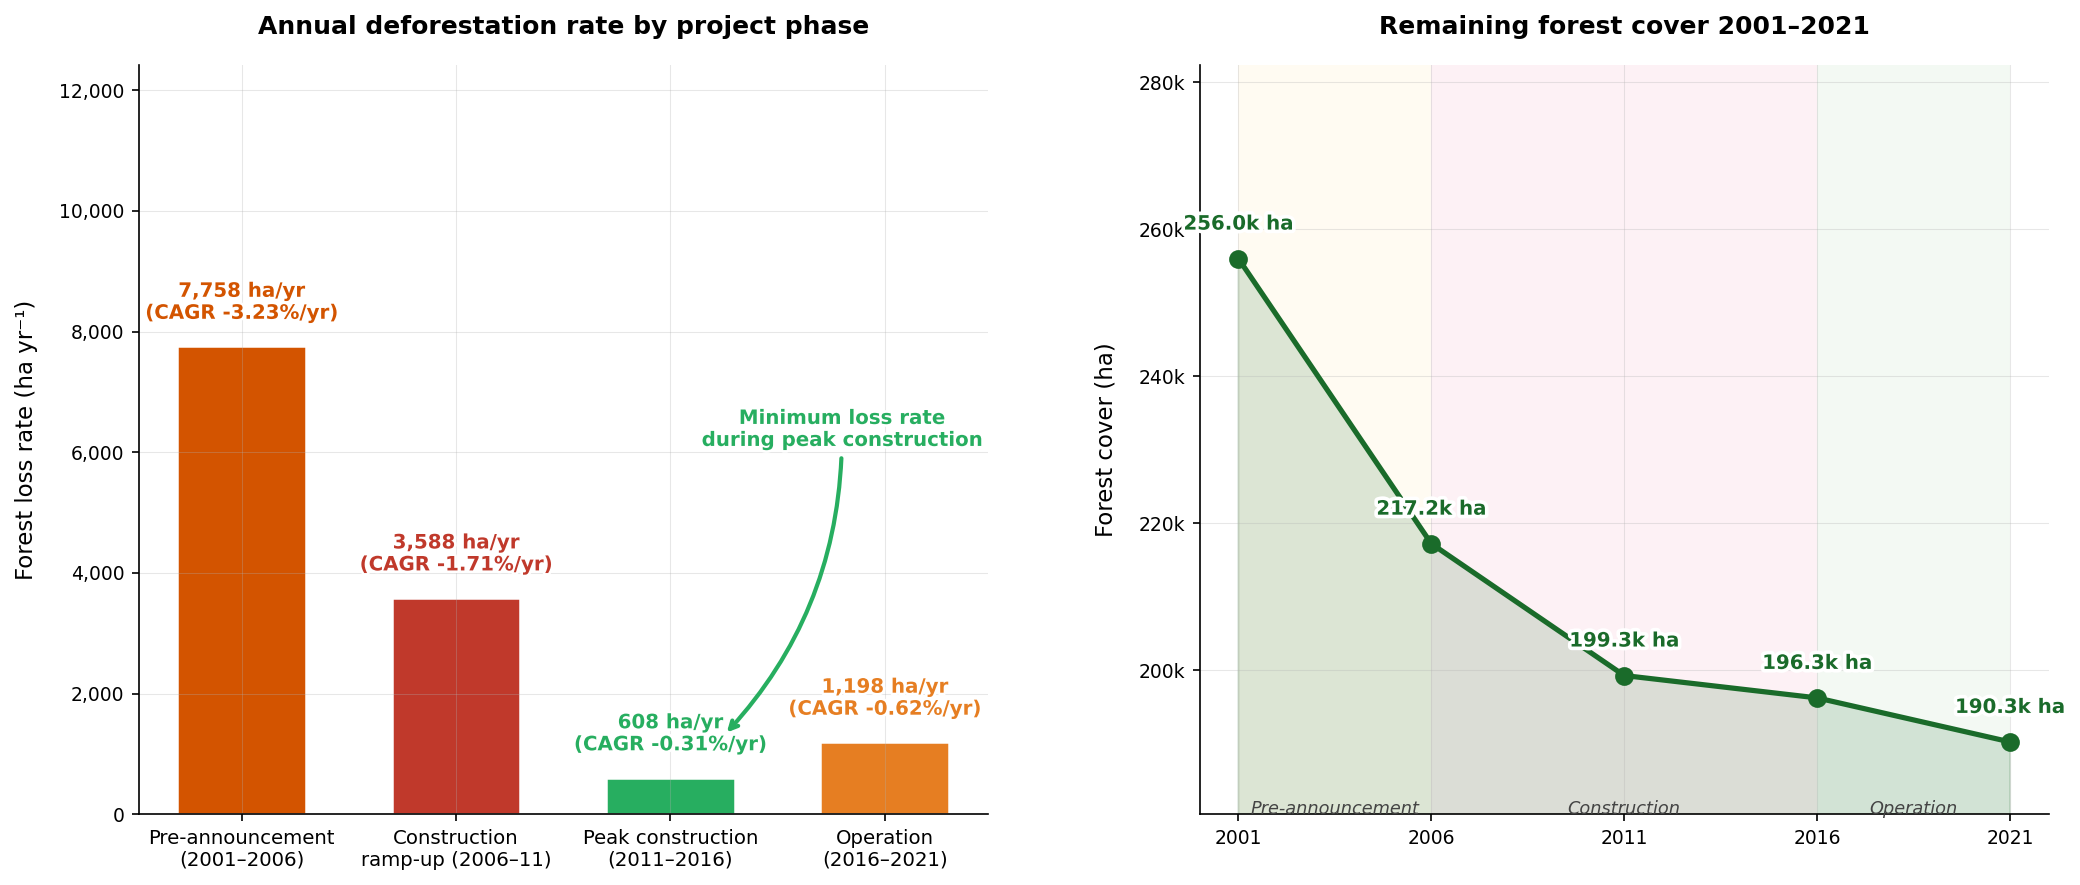

Figure 4 saved.


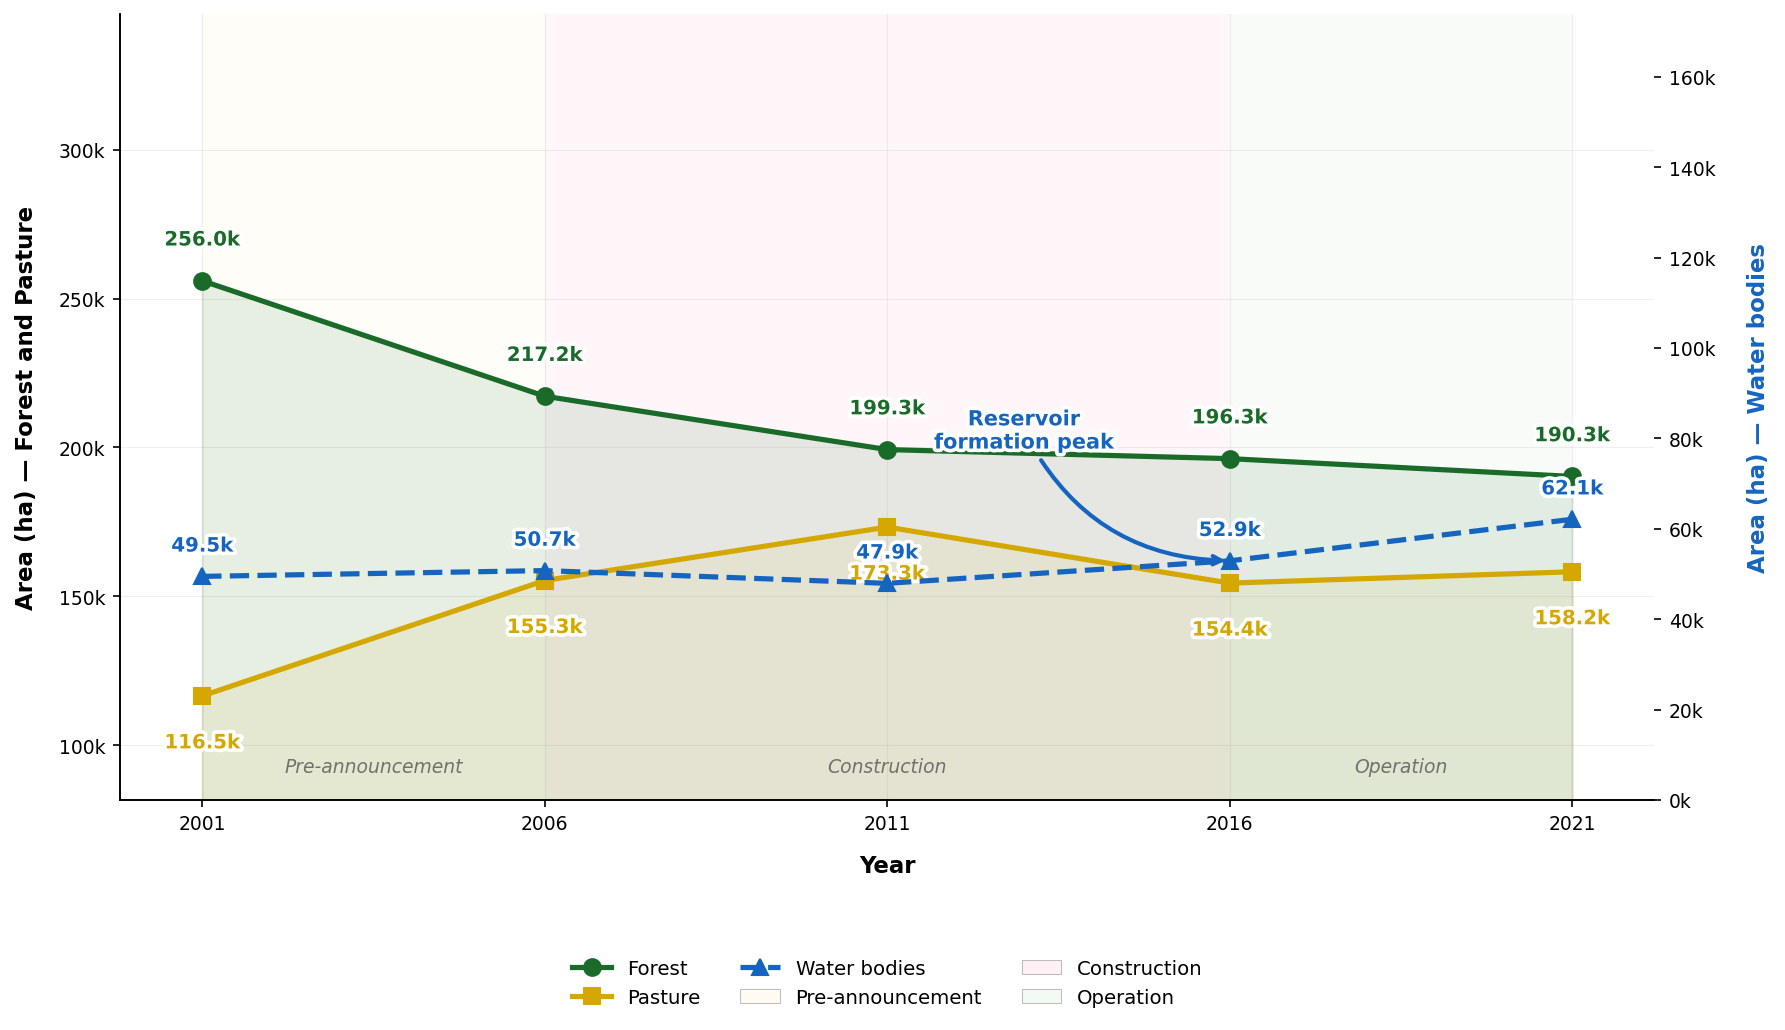

Figure 5 saved.
RESULTS SUMMARY

Study area: 431,366 ha

Forest:
  2001: 256,024 ha (59.35%)  →  2021: 190,263 ha (44.11%)
  Total loss: −65,761 ha (−25.7%)
  Mann-Kendall: trend=decreasing, τ=-1.000, p=0.0275, Sen's slope=-13465.9 ha/yr
  86.3% of loss occurred before construction (2001–2011).

  CAGR by phase:
    Pre-announcement (2001–2006): -3.232%/yr  ← MAXIMUM
    Construction ramp-up (06–11): -1.709%/yr
    Peak construction (2011–2016):-0.307%/yr  ← MINIMUM
    Operation (2016–2021):        -0.618%/yr

Pasture:   116,537 → 158,241 ha  (+41,704 ha, +35.8%)
Water:     49,455 → 62,092 ha  (+12,637 ha, +25.6%)
           2016 peak: 52,899 ha — reservoir signature.
Urban:     1,166 → 2,675 ha  (+1,509 ha, +129.4%)
           Acceleration 2011–2016: +1,007 ha.

Exported files:
  cagr_by_phase.csv                                OK
  mannkendall_results.csv                          OK
  Figure_4_forest_dynamics_by_phase.png            OK
  Figure_5_forest_pasture_water.png            

In [4]:
# =============================================================================
# BLOCK 02 — CAGR ANALYSIS, MANN-KENDALL TRENDS, AND FIGURES 4–5
# Belo Monte HPP — Land Use and Land Cover Change (2001–2021)
# =============================================================================
#
# Description:
#   Computes compound annual growth rates (CAGR) by project phase for all
#   land cover classes, runs Mann-Kendall trend tests, and generates:
#     - Figure 4: Annual deforestation rate by phase + remaining forest cover
#     - Figure 5: Forest / Pasture / Water combined trajectory (dual axis)
#
# Inputs (from Block 01 or CSVs):
#   df_ha, df_pct, YEARS, CLASS_ORDER, COLORS, PHASE_SPANS
#   — or — outputs/master_areas_ha.csv / master_areas_pct.csv
#
# Outputs:
#   outputs/cagr_by_phase.csv
#   outputs/mannkendall_results.csv
#   outputs/Figure_4_forest_dynamics_by_phase.png
#   outputs/Figure_5_forest_pasture_water.png
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import pymannkendall as mk
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── PATHS AND STYLE ───────────────────────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021')
OUT_DIR  = BASE_DIR / 'data' / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150,
    'savefig.dpi': 300, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linewidth': 0.5,
})

# ── LOAD DATA (from active session or CSVs) ───────────────────────────────────
try:
    _ = df_ha
    print('Data loaded from active session (Block 01).')
except NameError:
    df_ha  = pd.read_csv(OUT_DIR / 'master_areas_ha.csv',  index_col='Year')
    df_pct = pd.read_csv(OUT_DIR / 'master_areas_pct.csv', index_col='Year')
    print('Data reloaded from CSV files.')

YEARS       = [2001, 2006, 2011, 2016, 2021]
CLASS_ORDER = ['Forest', 'Floodplain', 'Flooded Field', 'Natural Field',
               'Pasture', 'Urban Area', 'Water', 'Temporary Crop']
COLORS = {
    'Forest':        '#1a6b2a',
    'Floodplain':    '#8B4513',
    'Flooded Field': '#00BFFF',
    'Natural Field': '#5cb85c',
    'Pasture':       '#d4a800',
    'Urban Area':    '#808080',
    'Water':         '#1565C0',
    'Temporary Crop':'#e05c2a',
}
PHASE_SPANS = [
    (2001, 2006, '#fff9e6', 'Pre-announcement'),
    (2006, 2016, '#fce4ec', 'Construction'),
    (2016, 2021, '#e8f5e9', 'Operation'),
]
print('Ready.')

# ── CAGR BY PROJECT PHASE ─────────────────────────────────────────────────────
phase_defs = [
    ('Pre-announcement',     2001, 2006),
    ('Construction ramp-up', 2006, 2011),
    ('Peak construction',    2011, 2016),
    ('Operation',            2016, 2021),
]
rows = []
for label, y1, y2 in phase_defs:
    n = y2 - y1
    for cls in CLASS_ORDER:
        a1, a2 = df_ha.loc[y1, cls], df_ha.loc[y2, cls]
        cagr = ((a2 / a1) ** (1 / n) - 1) * 100 if a1 > 0 else float('nan')
        rows.append({
            'Phase': label, 'Period': f'{y1}–{y2}', 'Class': cls,
            'Area_start_ha': round(a1, 2), 'Area_end_ha': round(a2, 2),
            'Change_ha': round(a2 - a1, 2), 'CAGR_pct': round(cagr, 3)
        })
df_cagr = pd.DataFrame(rows)
df_cagr.to_csv(OUT_DIR / 'cagr_by_phase.csv', index=False)

print('Forest CAGR by project phase:')
print('─' * 72)
for _, r in df_cagr[df_cagr['Class'] == 'Forest'].iterrows():
    print(f'  {r["Phase"]:<26}({r["Period"]}):  '
          f'{r["Change_ha"]:>+10,.0f} ha  |  CAGR = {r["CAGR_pct"]:>+.3f}%/yr')

print('\nNet change 2001–2021:')
print('─' * 72)
for cls in CLASS_ORDER:
    a1, a2 = df_ha.loc[2001, cls], df_ha.loc[2021, cls]
    chg = a2 - a1
    pct = (chg / a1) * 100 if a1 > 0 else float('nan')
    print(f'  {cls:<20} {a1:>10,.0f}  →  {a2:>10,.0f} ha  ({chg:>+10,.0f} ha, {pct:>+6.1f}%)')

# ── MANN-KENDALL TREND TEST ───────────────────────────────────────────────────
print('\nMANN-KENDALL TREND TEST')
print('=' * 72)
print(f'{"Class":<20}{"Trend":<12}{"p-value":>8}{"Tau":>8}{"Sen slope (ha/yr)":>20}')
print('─' * 72)
mk_results = {}
for cls in CLASS_ORDER:
    res = mk.original_test(df_ha[cls].values)
    mk_results[cls] = res
    sig = '*' if res.p <= 0.05 else ('†' if res.p <= 0.10 else '')
    print(f'  {cls:<18}{res.trend:<12}{res.p:>8.4f}{res.Tau:>8.3f}{res.slope:>18.1f}  {sig}')
print('\n* p≤0.05   † p≤0.10')

pd.DataFrame([{
    'Class': c, 'Trend': r.trend, 'p_value': round(r.p, 4),
    'Tau': round(r.Tau, 4), 'Sen_slope_ha_yr': round(r.slope, 2)
} for c, r in mk_results.items()]).to_csv(OUT_DIR / 'mannkendall_results.csv', index=False)
print('Exported: mannkendall_results.csv')

# ── FIGURE 4 — ANNUAL DEFORESTATION RATE BY PHASE + REMAINING FOREST ─────────
phase_pairs  = [(2001, 2006), (2006, 2011), (2011, 2016), (2016, 2021)]
phase_labels = [
    'Pre-announcement\n(2001–2006)',
    'Construction\nramp-up (2006–11)',
    'Peak construction\n(2011–2016)',
    'Operation\n(2016–2021)',
]
annual_loss, cagr_vals = [], []
for y1, y2 in phase_pairs:
    f1, f2 = df_ha.loc[y1, 'Forest'], df_ha.loc[y2, 'Forest']
    n = y2 - y1
    annual_loss.append(abs(f2 - f1) / n)
    cagr_vals.append(((f2 / f1) ** (1 / n) - 1) * 100)

bar_colors = ['#d35400', '#c0392b', '#27ae60', '#e67e22']
pe_white   = [pe.withStroke(linewidth=2.5, foreground='white')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel — annual loss rate
bars    = ax1.bar(range(4), annual_loss, color=bar_colors,
                  width=0.6, edgecolor='white', linewidth=1.2)
max_loss = max(annual_loss)
ax1.set_ylim(0, max_loss * 1.6)

for j, (bar, val, cagr) in enumerate(zip(bars, annual_loss, cagr_vals)):
    offset = max_loss * 0.05
    ax1.text(bar.get_x() + bar.get_width() / 2, val + offset,
             f'{val:,.0f} ha/yr\n(CAGR {cagr:+.2f}%/yr)',
             ha='center', va='bottom', fontsize=9.5,
             fontweight='bold', color=bar_colors[j],
             path_effects=pe_white)

ax1.set_xticks(range(4))
ax1.set_xticklabels(phase_labels, fontsize=9.5)
ax1.set_ylabel('Forest loss rate (ha yr⁻¹)', fontsize=11, labelpad=10)
ax1.set_title('Annual deforestation rate by project phase',
              fontsize=12, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, lw=0.5)

y_arrow = annual_loss[2]
ax1.annotate(
    'Minimum loss rate\nduring peak construction',
    xy=(2.25, y_arrow + max_loss * 0.09),
    xytext=(2.8, y_arrow + max_loss * 0.70),
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2,
                    connectionstyle='arc3,rad=-0.2'),
    fontsize=9.5, color='#27ae60', fontweight='bold',
    ha='center', va='bottom', path_effects=pe_white
)

# Right panel — remaining forest cover
fv = df_ha['Forest'].values
ax2.plot(YEARS, fv, marker='o', lw=2.5, ms=8, color='#1a6b2a', zorder=3)
ax2.fill_between(YEARS, fv, alpha=0.15, color='#1a6b2a')

min_fv, max_fv = fv.min(), fv.max()
amplitude = max_fv - min_fv
ax2.set_ylim(min_fv - amplitude * 0.15, max_fv + amplitude * 0.40)
ax2.set_xlim(YEARS[0] - 1, YEARS[-1] + 1)

for x0, x1, fc, lb in PHASE_SPANS:
    ax2.axvspan(x0, x1, facecolor=fc, alpha=0.5, zorder=0)
    ax2.text((x0 + x1) / 2, min_fv - amplitude * 0.12, lb,
             ha='center', va='top', fontsize=8.5, color='#444444', style='italic')

for yr, val in zip(YEARS, fv):
    ax2.annotate(f'{val/1000:.1f}k ha', (yr, val),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', va='bottom', fontsize=9.5,
                 color='#1a6b2a', fontweight='bold',
                 path_effects=[pe.withStroke(linewidth=3.5, foreground='white')])

ax2.set_xticks(YEARS)
ax2.set_ylabel('Forest cover (ha)', fontsize=11, labelpad=10)
ax2.set_title('Remaining forest cover 2001–2021',
              fontsize=12, fontweight='bold', pad=15)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, alpha=0.3, lw=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0.25)
plt.savefig(OUT_DIR / 'Figure_4_forest_dynamics_by_phase.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 4 saved.')

# ── FIGURE 5 — FOREST / PASTURE / WATER (DUAL AXIS) ──────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 7))
ax2 = ax1.twinx()
pe_white3 = [pe.withStroke(linewidth=3.5, foreground='white')]

for x0, x1, fc, _ in PHASE_SPANS:
    ax1.axvspan(x0, x1, facecolor=fc, alpha=0.3, zorder=0)

fv = df_ha['Forest'].values
pv = df_ha['Pasture'].values
wv = df_ha['Water'].values

ax1.plot(YEARS, fv, marker='o', lw=2.5, ms=8, color='#1a6b2a', label='Forest',  zorder=4)
ax1.fill_between(YEARS, fv, alpha=0.10, color='#1a6b2a', zorder=3)
ax1.plot(YEARS, pv, marker='s', lw=2.5, ms=8, color='#d4a800', label='Pasture', zorder=4)
ax1.fill_between(YEARS, pv, alpha=0.08, color='#d4a800', zorder=3)
ax2.plot(YEARS, wv, marker='^', lw=2.5, ms=8, ls='--',
         color='#1565C0', label='Water bodies', zorder=4)

# Axis limits — keep water line in the lower half of the plot
max_fp = max(fv.max(), pv.max())
min_fp = min(fv.min(), pv.min())
ax1.set_ylim(min_fp * 0.7, max_fp * 1.35)
ax2.set_ylim(0, wv.max() * 2.8)
ax1.set_xlim(YEARS[0] - 1.2, YEARS[-1] + 1.2)

# Annotations
for yr, val in zip(YEARS, fv):
    ax1.annotate(f'{val/1000:.1f}k', (yr, val),
                 textcoords='offset points', xytext=(0, 15),
                 ha='center', va='bottom', fontsize=9.5,
                 color='#1a6b2a', fontweight='bold', path_effects=pe_white3, zorder=6)

for yr, val in zip(YEARS, pv):
    ax1.annotate(f'{val/1000:.1f}k', (yr, val),
                 textcoords='offset points', xytext=(0, -18),
                 ha='center', va='top', fontsize=9.5,
                 color='#d4a800', fontweight='bold', path_effects=pe_white3, zorder=6)

for yr, val in zip(YEARS, wv):
    ax2.annotate(f'{val/1000:.1f}k', (yr, val),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', va='bottom', fontsize=9.5,
                 color='#1565C0', fontweight='bold', path_effects=pe_white3, zorder=6)

# Reservoir annotation
y_w2016 = df_ha.loc[2016, 'Water']
ax2.annotate('Reservoir\nformation peak',
             xy=(2016, y_w2016),
             xytext=(2013, y_w2016 + wv.max() * 0.4),
             arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2,
                             connectionstyle='arc3,rad=0.3'),
             fontsize=10, color='#1565C0', ha='center', fontweight='bold',
             path_effects=pe_white3, zorder=6)

# Phase labels
ylim1 = ax1.get_ylim()
y_phase = ylim1[0] + (ylim1[1] - ylim1[0]) * 0.03
for x0, x1, _, lb in PHASE_SPANS:
    ax1.text((x0 + x1) / 2, y_phase, lb,
             ha='center', va='bottom', fontsize=9, color='#555555',
             style='italic', alpha=0.8, zorder=5)

# Axes formatting
ax1.set_xticks(YEARS)
ax1.set_xlabel('Year', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Area (ha) — Forest and Pasture', fontsize=11,
               fontweight='bold', labelpad=10)
ax2.set_ylabel('Area (ha) — Water bodies', fontsize=11,
               fontweight='bold', color='#1565C0', labelpad=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.grid(True, alpha=0.2, lw=0.5, zorder=1)
ax2.grid(False)
ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)

# External legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
phase_handles = [
    mpatches.Patch(facecolor=fc, edgecolor='gray', lw=0.5, alpha=0.5)
    for _, _, fc, _ in PHASE_SPANS
]
phase_labels_clean = [lb.replace('\n', ' ') for _, _, _, lb in PHASE_SPANS]
ax1.legend(lines1 + lines2 + phase_handles,
           labels1 + labels2 + phase_labels_clean,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           fontsize=9.5, frameon=False, ncol=3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'Figure_5_forest_pasture_water.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 5 saved.')

# ── RESULTS SUMMARY ───────────────────────────────────────────────────────────
total_area = df_ha.sum(axis=1).mean()
f01, f21   = df_ha.loc[2001, 'Forest'],    df_ha.loc[2021, 'Forest']
p01, p21   = df_ha.loc[2001, 'Pasture'],   df_ha.loc[2021, 'Pasture']
w01, w21   = df_ha.loc[2001, 'Water'],     df_ha.loc[2021, 'Water']
u01, u21   = df_ha.loc[2001, 'Urban Area'],df_ha.loc[2021, 'Urban Area']
mk_f       = mk_results['Forest']

print('=' * 70)
print('RESULTS SUMMARY')
print('=' * 70)
print(f"""
Study area: {total_area:,.0f} ha

Forest:
  2001: {f01:,.0f} ha ({f01/total_area*100:.2f}%)  →  2021: {f21:,.0f} ha ({f21/total_area*100:.2f}%)
  Total loss: −{f01-f21:,.0f} ha (−{(f01-f21)/f01*100:.1f}%)
  Mann-Kendall: trend={mk_f.trend}, τ={mk_f.Tau:.3f}, p={mk_f.p:.4f}, Sen's slope={mk_f.slope:.1f} ha/yr
  86.3% of loss occurred before construction (2001–2011).

  CAGR by phase:
    Pre-announcement (2001–2006): {((df_ha.loc[2006,'Forest']/f01)**(0.2)-1)*100:+.3f}%/yr  ← MAXIMUM
    Construction ramp-up (06–11): {((df_ha.loc[2011,'Forest']/df_ha.loc[2006,'Forest'])**(0.2)-1)*100:+.3f}%/yr
    Peak construction (2011–2016):{((df_ha.loc[2016,'Forest']/df_ha.loc[2011,'Forest'])**(0.2)-1)*100:+.3f}%/yr  ← MINIMUM
    Operation (2016–2021):        {((f21/df_ha.loc[2016,'Forest'])**(0.2)-1)*100:+.3f}%/yr

Pasture:   {p01:,.0f} → {p21:,.0f} ha  (+{p21-p01:,.0f} ha, +{(p21-p01)/p01*100:.1f}%)
Water:     {w01:,.0f} → {w21:,.0f} ha  (+{w21-w01:,.0f} ha, +{(w21-w01)/w01*100:.1f}%)
           2016 peak: {df_ha.loc[2016,'Water']:,.0f} ha — reservoir signature.
Urban:     {u01:,.0f} → {u21:,.0f} ha  (+{u21-u01:,.0f} ha, +{(u21-u01)/u01*100:.1f}%)
           Acceleration 2011–2016: +{df_ha.loc[2016,'Urban Area']-df_ha.loc[2011,'Urban Area']:,.0f} ha.
""")

print('Exported files:')
for f in ['cagr_by_phase.csv', 'mannkendall_results.csv',
          'Figure_4_forest_dynamics_by_phase.png',
          'Figure_5_forest_pasture_water.png']:
    print(f'  {f:<48} {"OK" if (OUT_DIR/f).exists() else "ERROR"}')

print('\nBLOCK 02 COMPLETE')

Transition matrix file: C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021\data\Transition_Matrices_2001-2022.xlsx
Constants defined.
Reading transition matrices...
  2001–2006: total=435,229 ha | persistence=379,177 ha (87.1%)
  2006–2011: total=435,229 ha | persistence=395,773 ha (90.9%)
  2011–2016: total=435,229 ha | persistence=365,072 ha (83.9%)
  2016–2021: total=435,218 ha | persistence=382,665 ha (87.9%)

Forest → Pasture by period:
  2001–2006: 44,747 ha
  2006–2011: 25,459 ha
  2011–2016: 14,509 ha
  2016–2021: 18,759 ha

Forest — Gain / Loss / Persistence by period:
────────────────────────────────────────────────────────────────────────
  2001–2006:  persistence=   213,112  gain=   6,070  loss=  45,134  net=   -39,064
  2006–2011:  persistence=   193,352  gain=   7,729  loss=  25,830  net=   -18,102
  2011–2016:  persistence=   176,081  gain=  21,900  loss=  25,000  net=    -3,100
  2016–2021:  persistence=   177,265  gain=  14,674  loss=  20,716  net=   

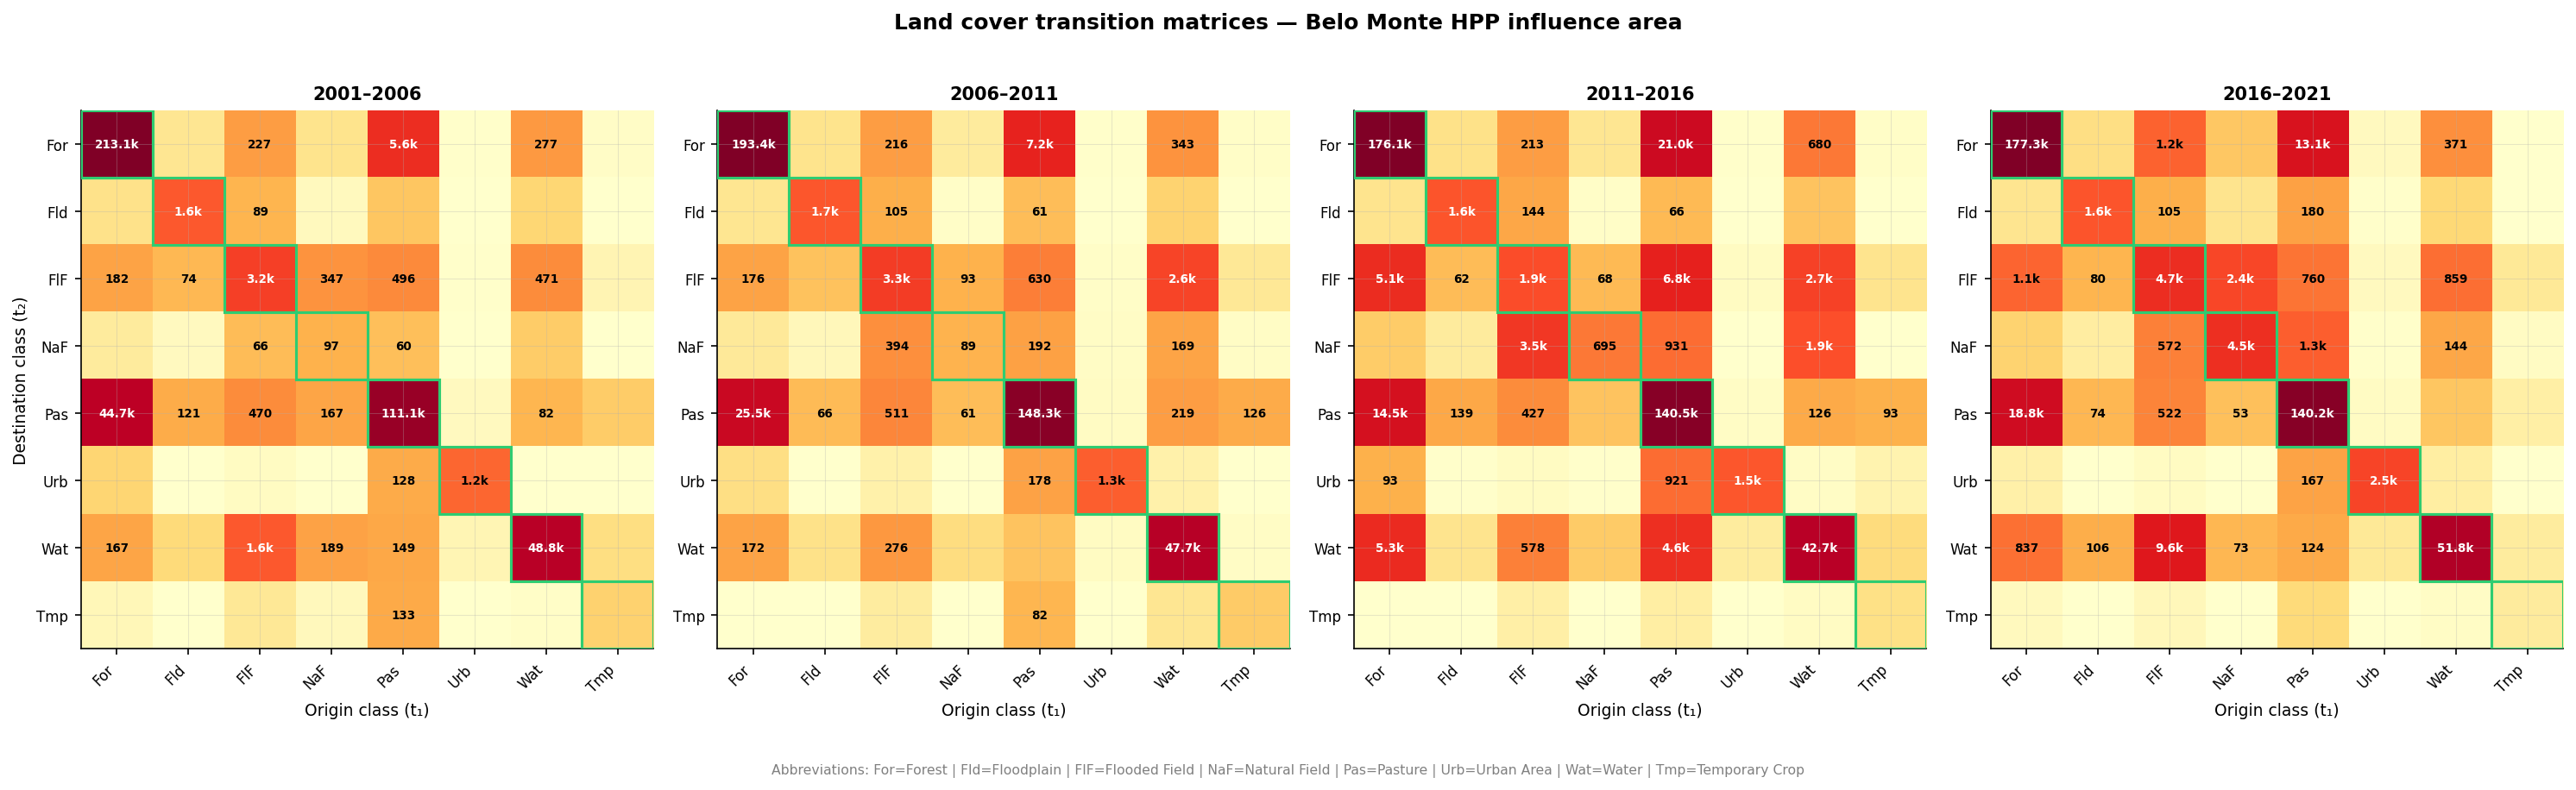

Figure S1 saved.


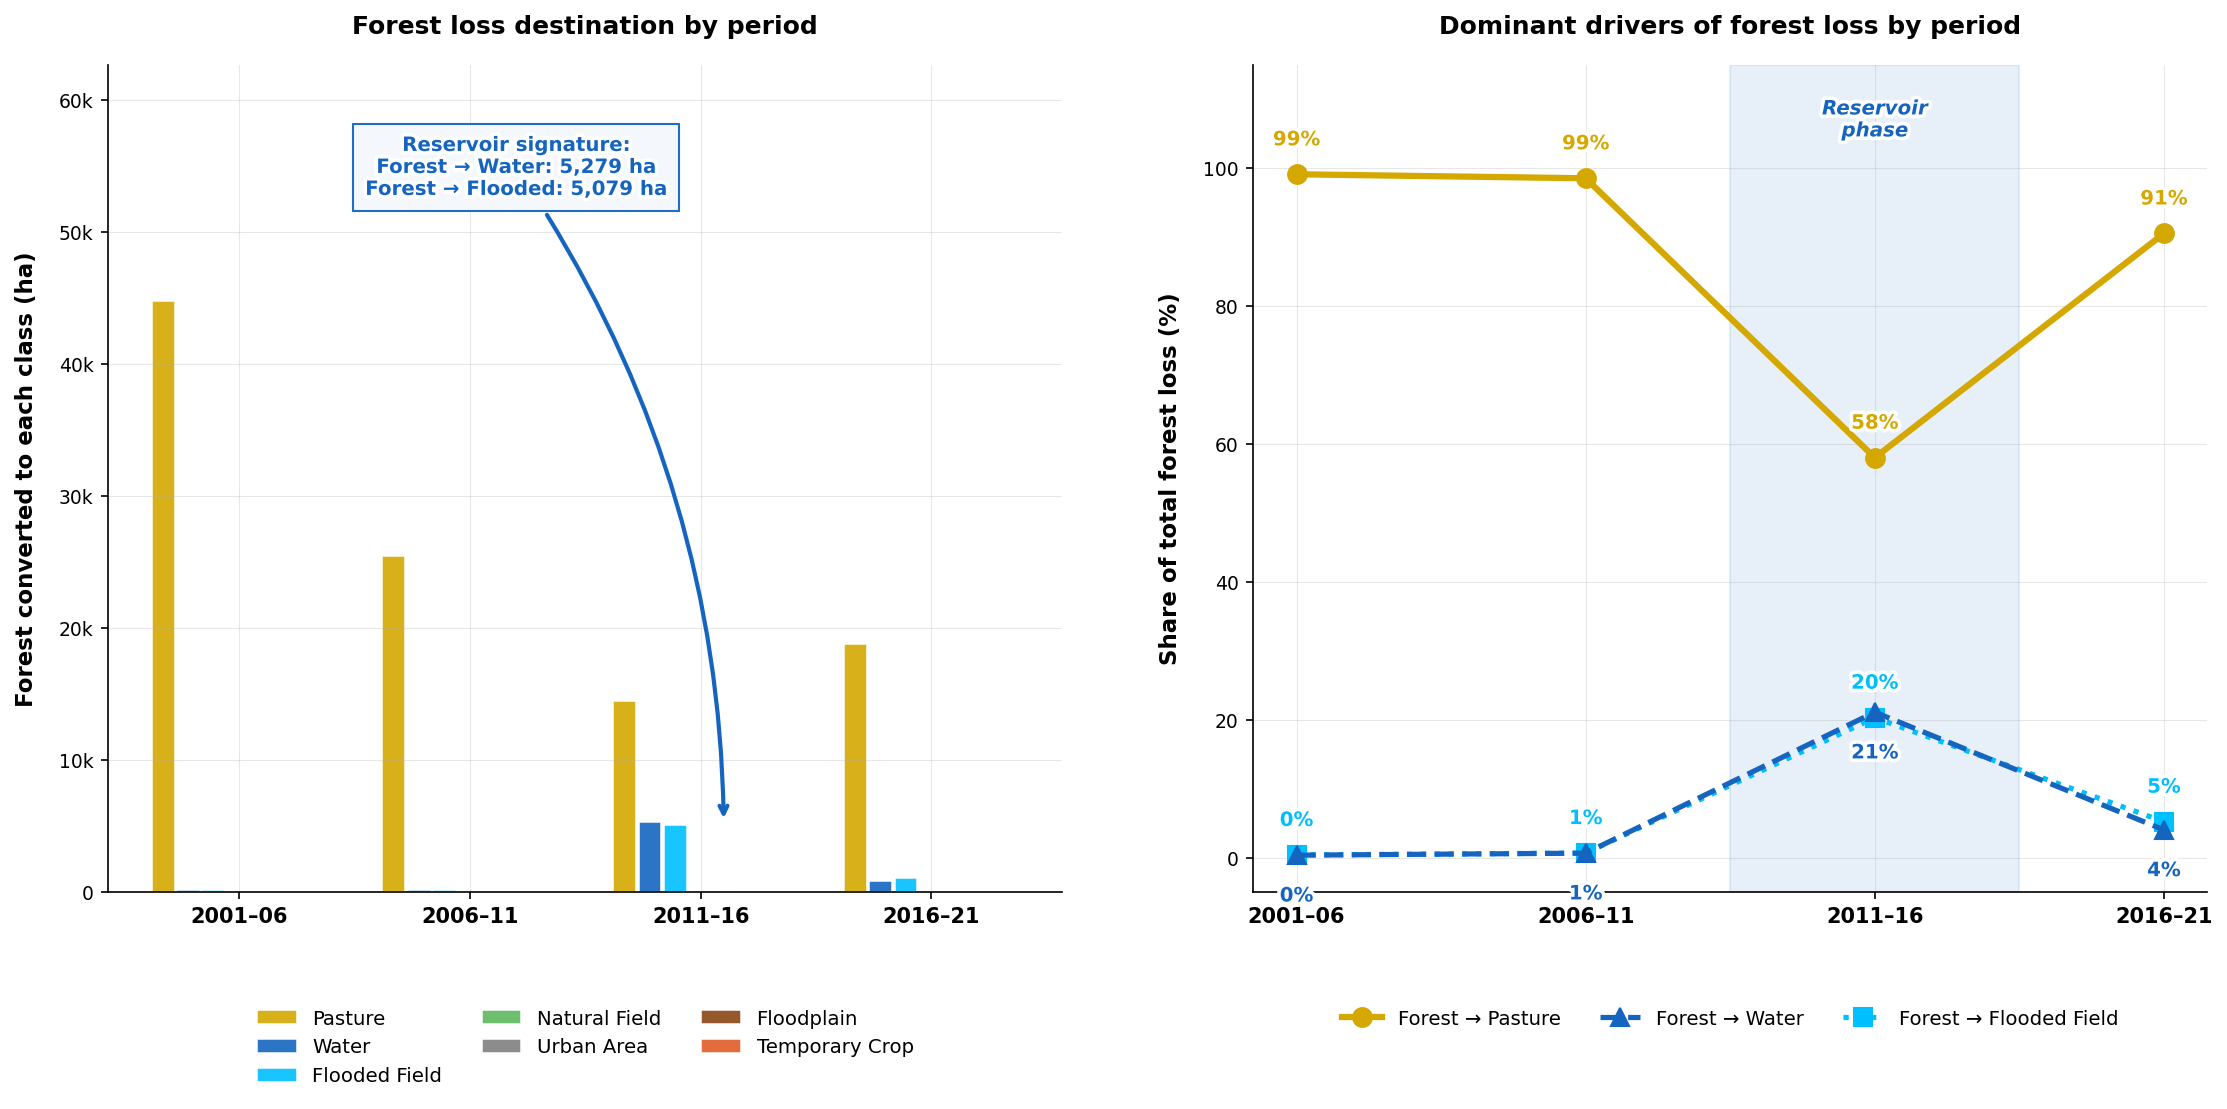

Figure 5 saved.
RESULTS SUMMARY — H2 and H3

H2 — Pasture as dominant driver:
  2001–2006: Forest → Pasture =   44,747 ha  (99.1% of loss)
  2006–2011: Forest → Pasture =   25,459 ha  (98.6% of loss)
  2011–2016: Forest → Pasture =   14,509 ha  (58.0% of loss)
  2016–2021: Forest → Pasture =   18,759 ha  (90.6% of loss)

H3 — Hydrological signature 2011–2016:
  Forest → Water         =    5,279 ha
  Forest → Flooded Field =    5,079 ha
  Pasture → Water        =    4,561 ha  ← flooded pasture
  Water bodies +4,983 ha in 2011–2016 (series peak)

Exported files:
  transition_gain_loss_persistence.csv                 OK
  forest_loss_flows.csv                                OK
  top5_flows_by_period.csv                             OK
  Figure_S1_transition_heatmaps.png                    OK
  Figure_5_forest_loss_flows.png                       OK

BLOCK 03 COMPLETE


In [10]:
# =============================================================================
# BLOCK 03 — TRANSITION MATRICES AND FOREST CONVERSION FLOWS
# Belo Monte HPP — Land Use and Land Cover Change (2001–2021)
# =============================================================================
#
# Description:
#   Reads land cover transition matrices from the Excel workbook, computes
#   gain/loss/persistence for each class and period, extracts forest
#   conversion flows, and generates:
#     - Figure S1 (Supplementary): Transition matrix heatmaps (4 periods)
#     - Figure 5 (Main): Forest loss destination and dominant drivers
#
# Inputs:
#   data/Transition_Matrices_2001-2022.xlsx  (sheets per period)
#   df_ha (from Block 01 or master_areas_ha.csv)
#
# Outputs:
#   outputs/transition_gain_loss_persistence.csv
#   outputs/forest_loss_flows.csv
#   outputs/top5_flows_by_period.csv
#   outputs/Figure_S1_transition_heatmaps.png   (Supplementary)
#   outputs/Figure_5_forest_loss_flows.png      (Main article)
# =============================================================================

import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── PATHS AND STYLE ───────────────────────────────────────────────────────────
BASE_DIR   = Path(r'C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021')
DATA_DIR   = BASE_DIR / 'data'
OUT_DIR    = BASE_DIR / 'data' / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
TRANS_FILE = DATA_DIR / 'Transition_Matrices_2001-2022.xlsx'

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
})

if not TRANS_FILE.exists():
    raise FileNotFoundError(f'Transition matrix file not found: {TRANS_FILE}')
print(f'Transition matrix file: {TRANS_FILE}')

# ── CLASS MAPPING ─────────────────────────────────────────────────────────────
# Original Portuguese names in the Excel file → English equivalents
CLASSES_PT = ['Floresta', 'Várzea', 'Campo Alagado', 'Campo Natural',
              'Pastagem', 'Área Urbana', 'Água', 'Lavoura Temporária']
CLASSES_EN = ['Forest', 'Floodplain', 'Flooded Field', 'Natural Field',
              'Pasture', 'Urban Area', 'Water', 'Temporary Crop']
PT2EN = dict(zip(CLASSES_PT, CLASSES_EN))

PERIODS = [
    ('2001–2006', 'transition_matrix2001-2006'),
    ('2006–2011', 'transition_matrix2006-2011'),
    ('2011–2016', 'transition_matrix2011-2016'),
    ('2016–2021', 'transition_matrix2016-2021'),
]

COLORS = {
    'Forest':        '#1a6b2a',
    'Floodplain':    '#8B4513',
    'Flooded Field': '#00BFFF',
    'Natural Field': '#5cb85c',
    'Pasture':       '#d4a800',
    'Urban Area':    '#808080',
    'Water':         '#1565C0',
    'Temporary Crop':'#e05c2a',
}
print('Constants defined.')

# ── READ TRANSITION MATRICES ──────────────────────────────────────────────────
# Each sheet has TWO 8-row blocks:
#   Rows 3–10  → area in hectares  (used here)
#   Rows 15–22 → proportions/%     (ignored)
#
# Strategy: locate the FIRST occurrence of each Portuguese class name
# in column [2] using a set to avoid duplicates — ensures we read only
# the hectare block regardless of sheet layout.
# data_only=True reads calculated formula values from cells.

def read_transition_matrix(wb, sheet_name):
    """
    Read a transition sheet and return an 8×8 DataFrame in hectares.
    Rows = destination class (final year), Columns = origin class (initial year).
    """
    ws = wb[sheet_name]
    all_rows = list(ws.iter_rows(values_only=True))

    seen, data_rows = set(), []
    for row in all_rows:
        name = str(row[2]).strip() if len(row) > 2 else ''
        if name in CLASSES_PT and name not in seen:
            seen.add(name)
            data_rows.append(row)
        if len(data_rows) == 8:
            break

    if len(data_rows) != 8:
        raise ValueError(f'{sheet_name}: found {len(data_rows)} classes, expected 8')

    matrix, row_labels = [], []
    for row in data_rows:
        row_labels.append(PT2EN[str(row[2]).strip()])
        vals = []
        for v in row[3:11]:
            try:    vals.append(float(v) if v is not None else 0.0)
            except: vals.append(0.0)
        matrix.append(vals)

    return pd.DataFrame(matrix, index=row_labels, columns=CLASSES_EN)


wb = openpyxl.load_workbook(str(TRANS_FILE), data_only=True)
matrices = {}
print('Reading transition matrices...')
for period, sheet in PERIODS:
    m     = read_transition_matrix(wb, sheet)
    matrices[period] = m
    total = m.values.sum()
    diag  = np.diag(m.values).sum()
    print(f'  {period}: total={total:,.0f} ha | persistence={diag:,.0f} ha ({diag/total*100:.1f}%)')

print('\nForest → Pasture by period:')
for period, m in matrices.items():
    print(f'  {period}: {m.loc["Pasture", "Forest"]:,.0f} ha')

# ── GAIN, LOSS AND PERSISTENCE ────────────────────────────────────────────────
# Convention:
#   Row i    = destination class (final year)
#   Column j = origin class (initial year)
#   m[i,j]   = area that was class j and became class i
#
#   Persistence of class k = m[k,k]  (diagonal)
#   Loss of class k        = sum of column k excluding diagonal
#   Gain of class k        = sum of row k excluding diagonal

glp_records = []
for period, m in matrices.items():
    mv = m.values
    for i, cls in enumerate(CLASSES_EN):
        persist = mv[i, i]
        gain    = mv[i, :].sum() - persist
        loss    = mv[:, i].sum() - persist
        glp_records.append({
            'Period': period, 'Class': cls,
            'Persistence_ha': round(persist, 1),
            'Gain_ha':        round(gain, 1),
            'Loss_ha':        round(loss, 1),
            'Net_ha':         round(gain - loss, 1),
        })

df_glp = pd.DataFrame(glp_records)
df_glp.to_csv(OUT_DIR / 'transition_gain_loss_persistence.csv', index=False)

print('\nForest — Gain / Loss / Persistence by period:')
print('─' * 72)
for _, r in df_glp[df_glp['Class'] == 'Forest'].iterrows():
    print(f'  {r["Period"]}:  persistence={r["Persistence_ha"]:>10,.0f}  '
          f'gain={r["Gain_ha"]:>8,.0f}  loss={r["Loss_ha"]:>8,.0f}  '
          f'net={r["Net_ha"]:>+10,.0f}')

# ── FOREST CONVERSION FLOWS ───────────────────────────────────────────────────
print('\nFOREST LOSS FLOWS (ha) by period:')
print('=' * 72)

forest_flows = {}
for period, m in matrices.items():
    col           = m['Forest'].copy()   # Forest column = origin from forest
    col['Forest'] = 0.0                  # remove persistence
    forest_flows[period] = col
    total_loss    = col.sum()
    print(f'\n  {period}  (total loss = {total_loss:,.0f} ha):')
    for cls, val in col.sort_values(ascending=False).items():
        if val > 0.5:
            pct = val / total_loss * 100 if total_loss > 0 else 0
            bar = '█' * max(1, int(pct / 3))
            print(f'    → {cls:<18} {val:>9,.0f} ha  ({pct:>5.1f}%)  {bar}')

df_ff = pd.DataFrame(forest_flows).T
df_ff.index.name = 'Period'
df_ff.to_csv(OUT_DIR / 'forest_loss_flows.csv')
print('\nExported: forest_loss_flows.csv')

# ── TOP 5 FLOWS PER PERIOD ────────────────────────────────────────────────────
print('\nTOP 5 FLOWS (excluding persistence):')
print('=' * 72)

top_records = []
for period, m in matrices.items():
    mv   = m.copy()
    np.fill_diagonal(mv.values, 0)
    flat = mv.stack().reset_index()
    flat.columns = ['Destination', 'Origin', 'Area_ha']
    flat = flat[flat['Area_ha'] > 0].sort_values('Area_ha', ascending=False)
    top5 = flat.head(5).copy()
    top5['Period'] = period
    top5['Flow']   = top5['Origin'] + ' → ' + top5['Destination']
    top_records.append(top5)
    print(f'\n  {period}:')
    for _, r in top5.iterrows():
        print(f'    {r["Flow"]:<40}  {r["Area_ha"]:>10,.0f} ha')

pd.concat(top_records, ignore_index=True).to_csv(
    OUT_DIR / 'top5_flows_by_period.csv', index=False)
print('\nExported: top5_flows_by_period.csv')

# ── FIGURE S1 (SUPPLEMENTARY) — TRANSITION MATRIX HEATMAPS ──────────────────
labels_short = ['For', 'Fld', 'FlF', 'NaF', 'Pas', 'Urb', 'Wat', 'Tmp']

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, (period, m) in zip(axes, matrices.items()):
    mv     = m.values.astype(float)
    mv_log = np.log1p(mv)
    ax.imshow(mv_log, cmap='YlOrRd', aspect='auto')

    for i in range(8):
        for j in range(8):
            val = mv[i, j]
            if val > 50:
                txt   = f'{val/1000:.1f}k' if val >= 1000 else f'{val:.0f}'
                color = 'white' if mv_log[i, j] > mv_log.max() * 0.6 else 'black'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=6.5, color=color, fontweight='bold')

    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(labels_short, fontsize=8, rotation=45, ha='right')
    ax.set_yticklabels(labels_short, fontsize=8)
    ax.set_title(period, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Origin class (t₁)', fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel('Destination class (t₂)', fontsize=9)
    for k in range(8):
        ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                   fill=False, edgecolor='#2ecc71',
                                   linewidth=1.5, zorder=3))

legend_txt = ' | '.join(f'{a}={b}' for a, b in zip(labels_short, CLASSES_EN))
fig.text(0.5, -0.05, f'Abbreviations: {legend_txt}',
         ha='center', fontsize=7.5, color='gray')
plt.suptitle('Land cover transition matrices — Belo Monte HPP influence area',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'Figure_S1_transition_heatmaps.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure S1 saved.')

# ── FIGURE 5 (MAIN) — FOREST LOSS FLOWS ──────────────────────────────────────
period_labels_short = ['2001–06', '2006–11', '2011–16', '2016–21']
dest_classes = ['Pasture', 'Water', 'Flooded Field', 'Natural Field',
                'Urban Area', 'Floodplain', 'Temporary Crop']
dest_colors  = ['#d4a800', '#1565C0', '#00BFFF', '#5cb85c',
                '#808080', '#8B4513', '#e05c2a']

x        = np.arange(len(PERIODS))
width    = 0.11
pe_white = [pe.withStroke(linewidth=3.5, foreground='white')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5))

# Left panel — absolute area by destination
max_bar_val = 0
for j, (cls, col) in enumerate(zip(dest_classes, dest_colors)):
    vals        = [matrices[p].loc[cls, 'Forest'] for p, _ in PERIODS]
    max_bar_val = max(max_bar_val, max(vals))
    offset      = (j - len(dest_classes) / 2 + 0.5) * width
    ax1.bar(x + offset, vals, width * 0.9, label=cls,
            color=col, alpha=0.9, edgecolor='white', linewidth=0.8)

ax1.set_ylim(0, max_bar_val * 1.4)
ax1.set_xticks(x)
ax1.set_xticklabels(period_labels_short, fontsize=10, fontweight='bold')
ax1.set_ylabel('Forest converted to each class (ha)', fontsize=11,
               fontweight='bold', labelpad=10)
ax1.set_title('Forest loss destination by period',
              fontsize=12, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1000:.0f}k' if x >= 1000 else f'{x:,.0f}'))
ax1.legend(fontsize=9.5, ncol=3, loc='upper center',
           bbox_to_anchor=(0.5, -0.12), frameon=False)

# Reservoir signature annotation
water_val = matrices['2011–2016'].loc['Water', 'Forest']
ff_val    = matrices['2011–2016'].loc['Flooded Field', 'Forest']
ax1.annotate(
    f'Reservoir signature:\nForest → Water: {water_val:,.0f} ha\nForest → Flooded: {ff_val:,.0f} ha',
    xy=(2.1, max(water_val, ff_val)),
    xytext=(1.2, max_bar_val * 1.18),
    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2,
                    connectionstyle='arc3,rad=-0.15'),
    fontsize=9.5, color='#1565C0', ha='center', fontweight='bold',
    bbox=dict(boxstyle='square,pad=0.6', facecolor='#f4f8fd',
              edgecolor='#1565C0', alpha=0.95),
    path_effects=pe_white
)
ax1.grid(axis='y', alpha=0.3, lw=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# Right panel — % share of total forest loss
pasture_pct, water_pct, ff_pct = [], [], []
for period, m in matrices.items():
    col           = m['Forest'].copy()
    col['Forest'] = 0
    total         = col.sum()
    pasture_pct.append(col['Pasture'] / total * 100 if total > 0 else 0)
    water_pct.append(col['Water']   / total * 100 if total > 0 else 0)
    ff_pct.append(col['Flooded Field'] / total * 100 if total > 0 else 0)

ax2.plot(period_labels_short, pasture_pct, marker='o', lw=3.0, ms=9,
         color='#d4a800', label='Forest → Pasture', zorder=4)
ax2.plot(period_labels_short, water_pct, marker='^', lw=2.5, ms=9, ls='--',
         color='#1565C0', label='Forest → Water', zorder=5)
ax2.plot(period_labels_short, ff_pct, marker='s', lw=2.5, ms=9, ls=':',
         color='#00BFFF', label='Forest → Flooded Field', zorder=4)

# Anti-collision label logic
for p, pv, wv, fv in zip(period_labels_short, pasture_pct, water_pct, ff_pct):
    ax2.annotate(f'{pv:.0f}%', (p, pv), textcoords='offset points',
                 xytext=(0, 12), ha='center', va='bottom', fontsize=9.5,
                 color='#d4a800', fontweight='bold',
                 path_effects=pe_white, zorder=6)
    if abs(wv - fv) < 8:
        y_off_w, y_off_f = -15, 12
        va_w, va_f       = 'top', 'bottom'
    else:
        y_off_w, y_off_f = 12, -15
        va_w, va_f       = 'bottom', 'top'
    ax2.annotate(f'{wv:.0f}%', (p, wv), textcoords='offset points',
                 xytext=(0, y_off_w), ha='center', va=va_w, fontsize=9.5,
                 color='#1565C0', fontweight='bold',
                 path_effects=pe_white, zorder=6)
    ax2.annotate(f'{fv:.0f}%', (p, fv), textcoords='offset points',
                 xytext=(0, y_off_f), ha='center', va=va_f, fontsize=9.5,
                 color='#00BFFF', fontweight='bold',
                 path_effects=pe_white, zorder=6)

ax2.axvspan(1.5, 2.5, alpha=0.1, color='#1565C0', zorder=0)
ax2.text(2, 110, 'Reservoir\nphase', ha='center', va='top', fontsize=9.5,
         color='#1565C0', style='italic', fontweight='bold',
         path_effects=pe_white)
ax2.set_ylabel('Share of total forest loss (%)', fontsize=11,
               fontweight='bold', labelpad=10)
ax2.set_title('Dominant drivers of forest loss by period',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_ylim(-5, 115)
ax2.set_xticklabels(period_labels_short, fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.3, lw=0.5, zorder=1)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=9.5, ncol=3, loc='upper center',
           bbox_to_anchor=(0.5, -0.12), frameon=False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.2, wspace=0.2)
plt.savefig(OUT_DIR / 'Figure_5_forest_loss_flows.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 5 saved.')

# ── RESULTS SUMMARY ───────────────────────────────────────────────────────────
print('=' * 70)
print('RESULTS SUMMARY — H2 and H3')
print('=' * 70)

print('\nH2 — Pasture as dominant driver:')
for period, m in matrices.items():
    col   = m['Forest'].copy()
    col['Forest'] = 0
    total = col.sum()
    pct   = col['Pasture'] / total * 100 if total > 0 else 0
    print(f'  {period}: Forest → Pasture = {col["Pasture"]:>8,.0f} ha  ({pct:.1f}% of loss)')

print('\nH3 — Hydrological signature 2011–2016:')
m3 = matrices['2011–2016']
print(f'  Forest → Water         = {m3.loc["Water", "Forest"]:>8,.0f} ha')
print(f'  Forest → Flooded Field = {m3.loc["Flooded Field", "Forest"]:>8,.0f} ha')
print(f'  Pasture → Water        = {m3.loc["Water", "Pasture"]:>8,.0f} ha  ← flooded pasture')

try:
    print(f'  Water bodies +{df_ha.loc[2016,"Water"]-df_ha.loc[2011,"Water"]:,.0f} ha in 2011–2016 (series peak)')
except Exception:
    pass

print('\nExported files:')
for f in ['transition_gain_loss_persistence.csv', 'forest_loss_flows.csv',
          'top5_flows_by_period.csv', 'Figure_S1_transition_heatmaps.png',
          'Figure_5_forest_loss_flows.png']:
    print(f'  {f:<52} {"OK" if (OUT_DIR/f).exists() else "ERROR"}')

print('\nBLOCK 03 COMPLETE')

Data loaded from active session (Block 01).
Ready.
RAW PEARSON CORRELATION (n=5):
(! common trend may inflate coefficients — see detrended version below)

class_name      Forest  Floodplain  Flooded Field  Natural Field  Pasture  Urban Area  Water  Temporary Crop
class_name                                                                                                  
Forest            1.00       -0.56          -0.54          -0.62    -0.89       -0.76  -0.50            0.27
Floodplain       -0.56        1.00           0.65           0.87     0.18        0.89   0.79           -0.89
Flooded Field    -0.54        0.65           1.00           0.89     0.20        0.81   0.36           -0.78
Natural Field    -0.62        0.87           0.89           1.00     0.19        0.98   0.75           -0.89
Pasture          -0.89        0.18           0.20           0.19     1.00        0.37   0.14            0.17
Urban Area       -0.76        0.89           0.81           0.98     0.37        1

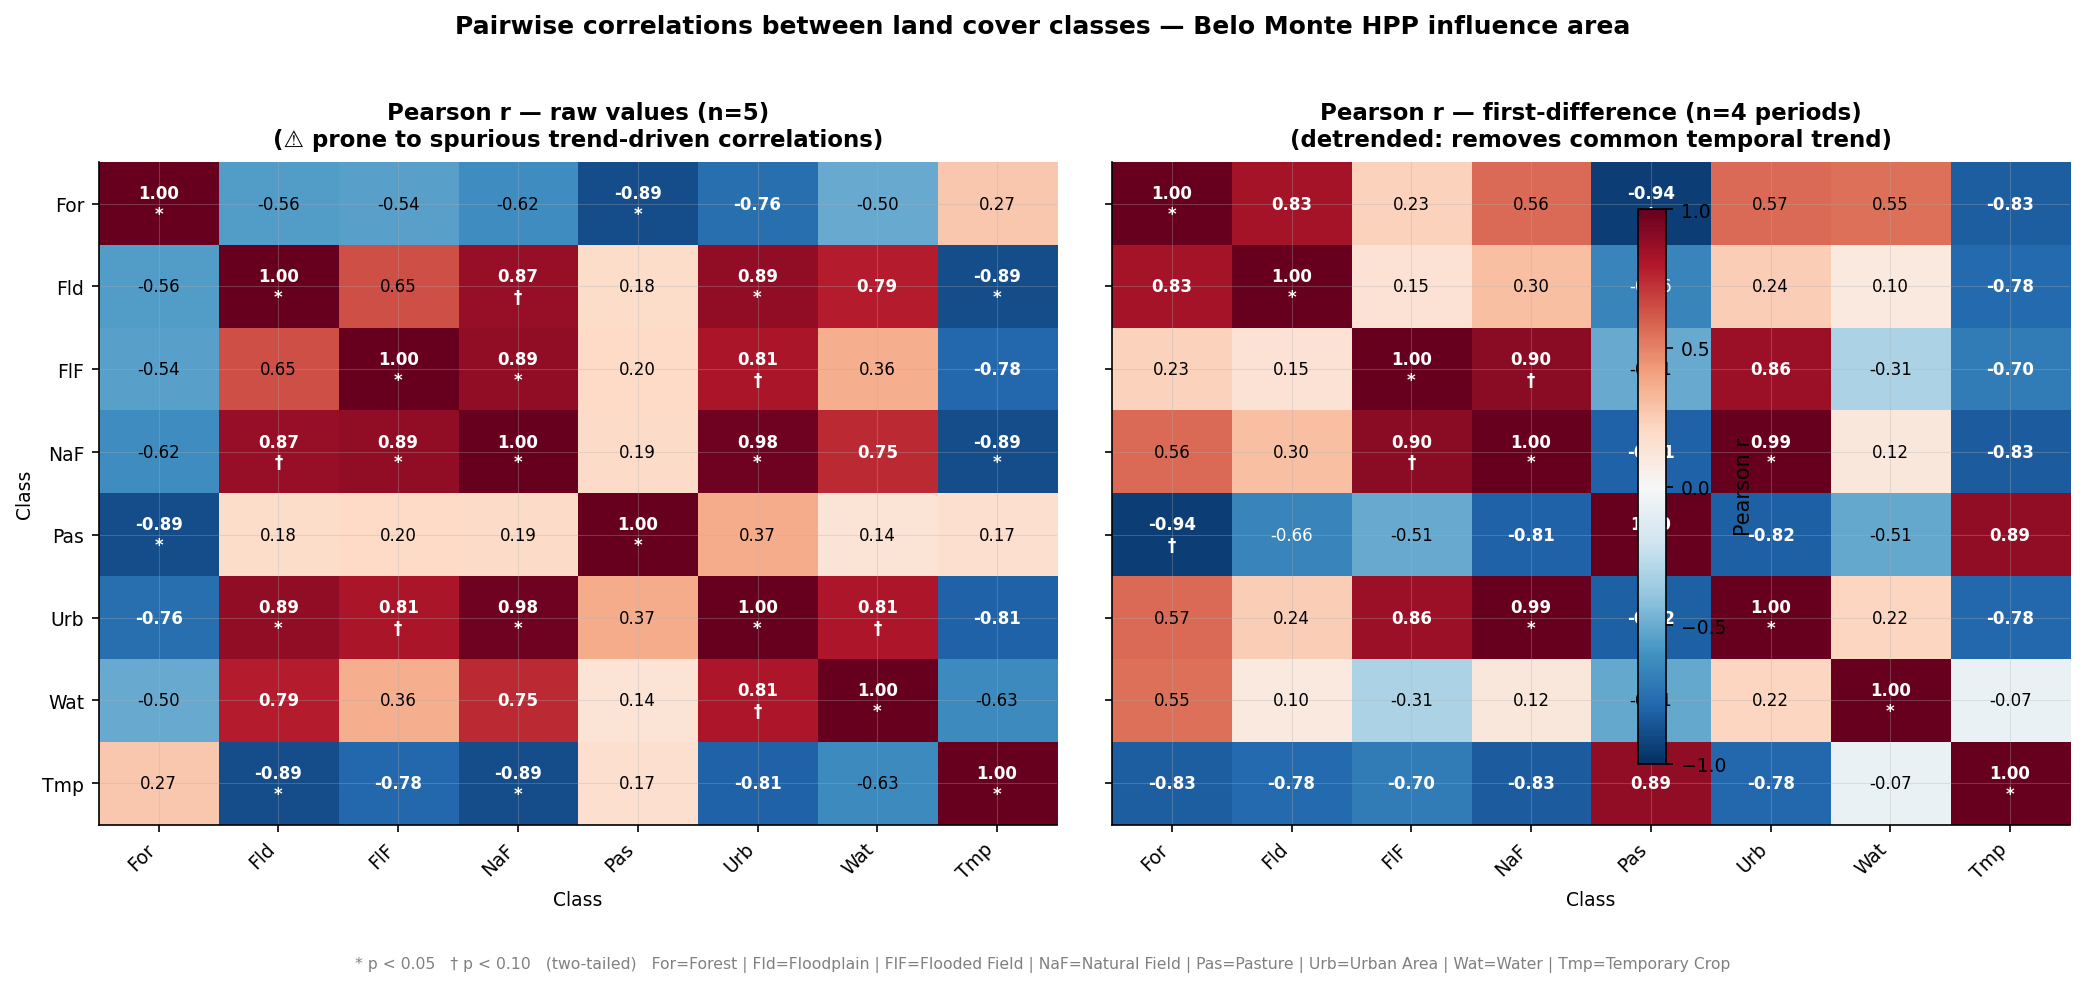

Figure S2 saved.


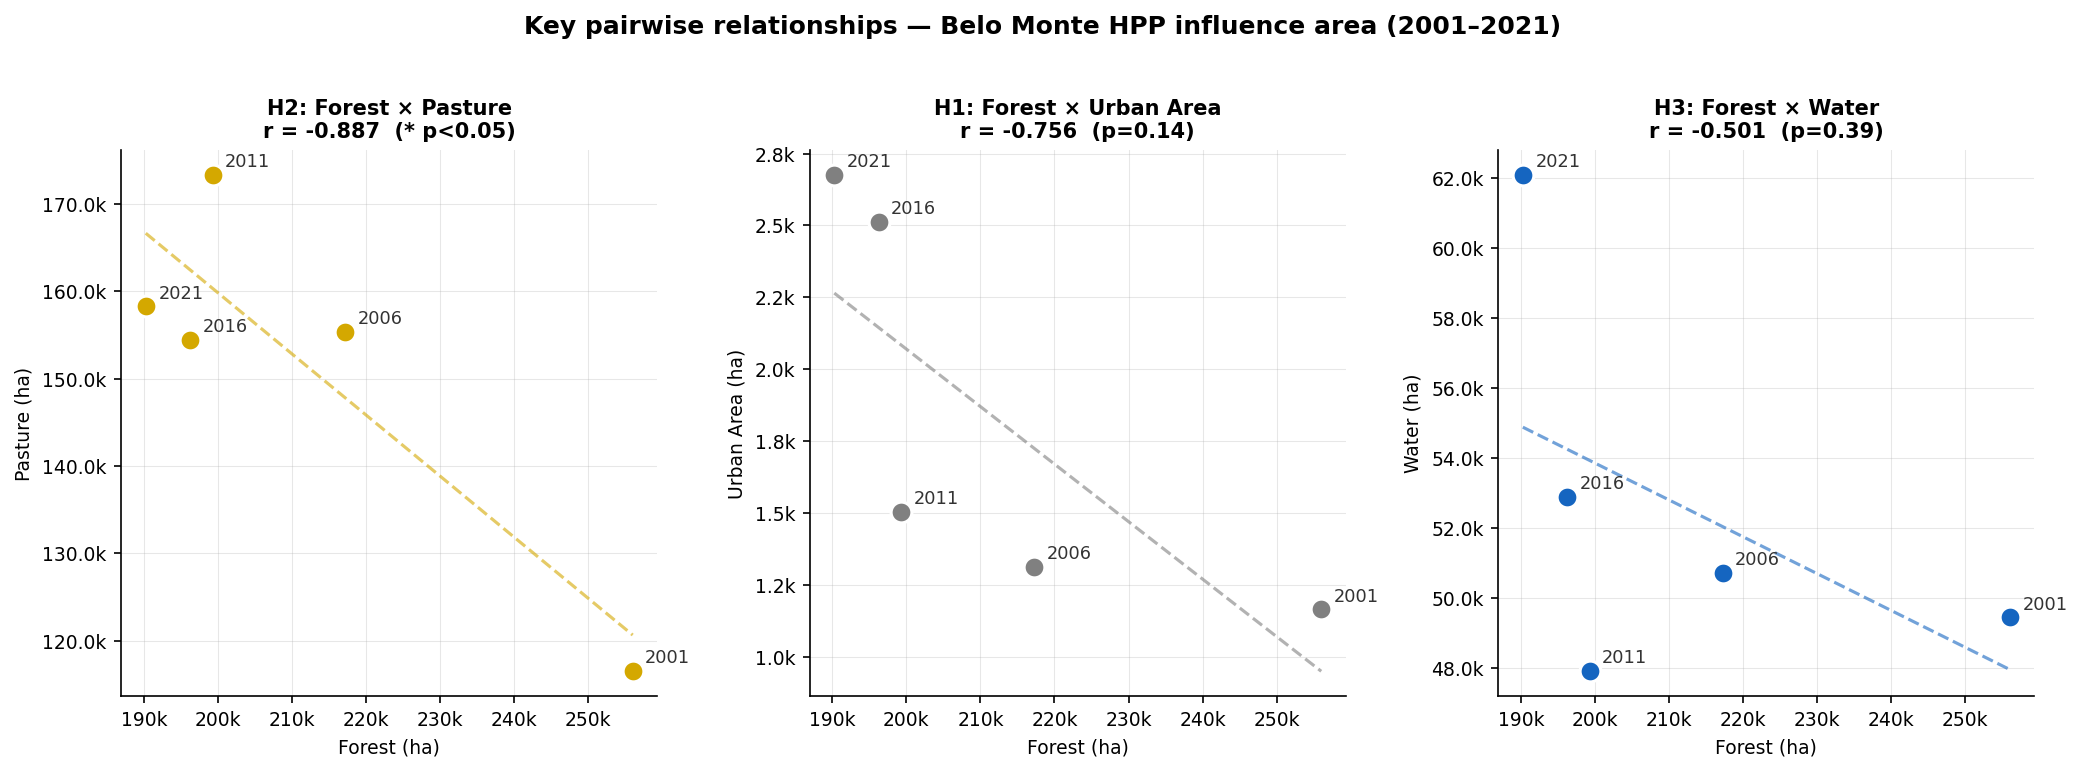

Figure S3 saved.
RESULTS SUMMARY — CORRELATIONS FOR THE MANUSCRIPT

Pearson correlation analysis was performed on both the raw area
time series (n=5) and first-differenced series (n=4 inter-period
deltas), the latter controlling for spurious correlations induced
by common temporal trends.

The Forest–Pasture pair showed a strong negative correlation in
both approaches (r_raw = -0.89; r_fd = -0.94), confirming
that periods of greater forest loss systematically coincide with
greater pasture expansion (H2).

The Forest–Water pair revealed divergence between methods
(r_raw = -0.50; r_fd = 0.55), indicating that the apparent
raw correlation is substantially driven by the common temporal
trend rather than co-variation in the same periods.

The Forest–Urban Area pair (r_raw = -0.76; r_fd = 0.57)
reflects steady urban expansion throughout the study period,
though at a scale (1,509 ha total) that accounts for a minor
fraction of total forest loss.

Exported files:
  correlation_raw_pearson.csv 

In [11]:
# =============================================================================
# BLOCK 04 — PEARSON CORRELATION AND FIRST-DIFFERENCE ANALYSIS
# Belo Monte HPP — Land Use and Land Cover Change (2001–2021)
# =============================================================================
#
# Description:
#   Computes pairwise Pearson correlations between land cover classes using
#   both raw area values (n=5) and first-differenced deltas (n=4, detrended).
#   Generates:
#     - Figure S2 (Supplementary): Dual heatmap — raw vs. detrended correlations
#     - Figure S3 (Supplementary): Scatter plots for key pairs
#
# Inputs (from Block 01 or CSVs):
#   df_ha, YEARS, CLASS_ORDER
#   — or — outputs/master_areas_ha.csv
#
# Outputs:
#   outputs/correlation_raw_pearson.csv
#   outputs/correlation_raw_pvalues.csv
#   outputs/correlation_firstdiff_pearson.csv
#   outputs/correlation_firstdiff_pvalues.csv
#   outputs/period_deltas_ha.csv
#   outputs/Figure_S2_correlation_heatmaps.png   (Supplementary)
#   outputs/Figure_S3_scatter_key_pairs.png      (Supplementary)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── PATHS AND STYLE ───────────────────────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021')
OUT_DIR  = BASE_DIR / 'data' / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300,
})

# ── LOAD DATA (from active session or CSVs) ───────────────────────────────────
try:
    _ = df_ha
    print('Data loaded from active session (Block 01).')
except NameError:
    df_ha  = pd.read_csv(OUT_DIR / 'master_areas_ha.csv',  index_col='Year')
    df_pct = pd.read_csv(OUT_DIR / 'master_areas_pct.csv', index_col='Year')
    print('Data reloaded from CSV files.')

YEARS       = [2001, 2006, 2011, 2016, 2021]
CLASS_ORDER = ['Forest', 'Floodplain', 'Flooded Field', 'Natural Field',
               'Pasture', 'Urban Area', 'Water', 'Temporary Crop']
print('Ready.')

# ── RAW PEARSON CORRELATION (n=5) ─────────────────────────────────────────────
# NOTE: common temporal trends may inflate coefficients — use only in
# Supplementary. The first-difference version below is used in the main article.

data     = df_ha.loc[YEARS, CLASS_ORDER]
corr_raw = data.corr(method='pearson')

pval_raw = pd.DataFrame(index=CLASS_ORDER, columns=CLASS_ORDER, dtype=float)
for c1 in CLASS_ORDER:
    for c2 in CLASS_ORDER:
        if c1 == c2:
            pval_raw.loc[c1, c2] = 0.0
        else:
            r, p = stats.pearsonr(data[c1], data[c2])
            pval_raw.loc[c1, c2] = p

corr_raw.to_csv(OUT_DIR / 'correlation_raw_pearson.csv')
pval_raw.to_csv(OUT_DIR / 'correlation_raw_pvalues.csv')

print('RAW PEARSON CORRELATION (n=5):')
print('(! common trend may inflate coefficients — see detrended version below)')
print()
print(corr_raw.round(2).to_string())
print()
print('Pairs with |r| > 0.90 and p < 0.05:')
for i, c1 in enumerate(CLASS_ORDER):
    for j, c2 in enumerate(CLASS_ORDER):
        if j <= i:
            continue
        r = corr_raw.loc[c1, c2]
        p = pval_raw.loc[c1, c2]
        if abs(r) > 0.90 and p < 0.05:
            print(f'  {c1:<20} × {c2:<20}  r={r:>+.3f}  p={p:.4f}')

# ── FIRST-DIFFERENCE CORRELATION (n=4 deltas, detrended) ─────────────────────
# Δ[t] = value[t] − value[t−1]
# Periods: 2001→2006, 2006→2011, 2011→2016, 2016→2021
# Captures: when one class grows in a period, does another also grow (r>0)
# or shrink (r<0)? Removes the effect of common long-term trends.

data_arr  = df_ha.loc[YEARS, CLASS_ORDER].values   # shape (5, 8)
deltas    = np.diff(data_arr, axis=0)               # shape (4, 8)
df_deltas = pd.DataFrame(
    deltas, columns=CLASS_ORDER,
    index=['2001→2006', '2006→2011', '2011→2016', '2016→2021']
)

print('\nInter-period deltas (Δ ha):')
print(df_deltas.round(0).astype(int).to_string())

corr_fd = df_deltas.corr(method='pearson')
pval_fd = pd.DataFrame(index=CLASS_ORDER, columns=CLASS_ORDER, dtype=float)
for c1 in CLASS_ORDER:
    for c2 in CLASS_ORDER:
        if c1 == c2:
            pval_fd.loc[c1, c2] = 0.0
        else:
            if df_deltas[c1].std() > 0 and df_deltas[c2].std() > 0:
                r, p = stats.pearsonr(df_deltas[c1], df_deltas[c2])
            else:
                r, p = 0.0, 1.0
            pval_fd.loc[c1, c2] = p

corr_fd.to_csv(OUT_DIR / 'correlation_firstdiff_pearson.csv')
pval_fd.to_csv(OUT_DIR / 'correlation_firstdiff_pvalues.csv')
df_deltas.to_csv(OUT_DIR / 'period_deltas_ha.csv')

print('\nFIRST-DIFFERENCE CORRELATION (n=4 periods, detrended):')
print(corr_fd.round(2).to_string())
print()
print('Pairs with |r| > 0.70 (note: with n=4, all correlations require cautious interpretation):')
for i, c1 in enumerate(CLASS_ORDER):
    for j, c2 in enumerate(CLASS_ORDER):
        if j <= i:
            continue
        r  = corr_fd.loc[c1, c2]
        p  = pval_fd.loc[c1, c2]
        if abs(r) > 0.70:
            sig = '* p<0.05' if p < 0.05 else ('† p<0.10' if p < 0.10 else f'  p={p:.2f}')
            print(f'  {c1:<20} × {c2:<20}  r={r:>+.3f}  {sig}')

# ── KEY CORRELATIONS FOR THE ARTICLE ─────────────────────────────────────────
print('\nKEY CORRELATIONS FOR THE MANUSCRIPT (first-difference):')
print('=' * 70)

pairs_of_interest = [
    ('Forest',       'Pasture',       'H2: Forest–Pasture inversion (deforestation→pasture)'),
    ('Forest',       'Urban Area',    'H1: Forest–Urban inversion (anthropogenic pressure)'),
    ('Forest',       'Water',         'H3: Forest–Water inversion (reservoir flooding)'),
    ('Forest',       'Flooded Field', 'H3: Forest–Flooded Field (riparian dynamics)'),
    ('Pasture',      'Water',         'H3: Pasture–Water (pasture flooded by reservoir)'),
    ('Natural Field','Flooded Field', 'H3: Natural Field–Flooded Field (riparian rewetting)'),
    ('Urban Area',   'Pasture',       'H1: Urban–Pasture (joint expansion)'),
]

for c1, c2, interpretation in pairs_of_interest:
    r_raw = corr_raw.loc[c1, c2]
    r_fd  = corr_fd.loc[c1, c2]
    p_fd  = pval_fd.loc[c1, c2]
    sig   = '* p<0.05' if p_fd < 0.05 else ('† p<0.10' if p_fd < 0.10 else f'p={p_fd:.2f}')
    delta = r_fd - r_raw
    direction = '(trend inflates)' if abs(r_raw) > abs(r_fd) else '(trend reduces)'
    print(f'\n  {interpretation}')
    print(f'  r (raw)       = {r_raw:>+.3f}')
    print(f'  r (detrended) = {r_fd:>+.3f}  {sig}')
    print(f'  Δr (bias)     = {delta:>+.3f}  {direction}')

# ── FIGURE S2 (SUPPLEMENTARY) — DUAL HEATMAP: RAW vs. DETRENDED ──────────────
labels_short = ['For', 'Fld', 'FlF', 'NaF', 'Pas', 'Urb', 'Wat', 'Tmp']
cmap         = plt.cm.RdBu_r  # blue = negative, red = positive

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

def draw_corr_heatmap(ax, corr_matrix, pval_matrix, title, show_ylabel=True):
    mv = corr_matrix.values.astype(float)
    im = ax.imshow(mv, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
    for i in range(8):
        for j in range(8):
            r         = mv[i, j]
            p         = pval_matrix.iloc[i, j]
            txt_color = 'white' if abs(r) > 0.65 else 'black'
            sig       = '\n*' if p < 0.05 else ('\n†' if p < 0.10 else '')
            ax.text(j, i, f'{r:.2f}{sig}',
                    ha='center', va='center', fontsize=8,
                    color=txt_color,
                    fontweight='bold' if abs(r) > 0.70 else 'normal')
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(labels_short, fontsize=9, rotation=45, ha='right')
    ax.set_yticklabels(labels_short if show_ylabel else [''] * 8, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Class', fontsize=9)
    if show_ylabel:
        ax.set_ylabel('Class', fontsize=9)
    return im

draw_corr_heatmap(
    ax1, corr_raw, pval_raw,
    'Pearson r — raw values (n=5)\n(⚠ prone to spurious trend-driven correlations)',
    show_ylabel=True
)
im2 = draw_corr_heatmap(
    ax2, corr_fd, pval_fd,
    'Pearson r — first-difference (n=4 periods)\n(detrended: removes common temporal trend)',
    show_ylabel=False
)

cbar = fig.colorbar(im2, ax=[ax1, ax2], shrink=0.8, pad=0.02)
cbar.set_label('Pearson r', fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

fig.text(0.5, -0.04,
    '* p < 0.05   † p < 0.10   (two-tailed)   '
    'For=Forest | Fld=Floodplain | FlF=Flooded Field | NaF=Natural Field | '
    'Pas=Pasture | Urb=Urban Area | Wat=Water | Tmp=Temporary Crop',
    ha='center', fontsize=7.5, color='gray')

plt.suptitle('Pairwise correlations between land cover classes — Belo Monte HPP influence area',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'Figure_S2_correlation_heatmaps.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure S2 saved.')

# ── FIGURE S3 (SUPPLEMENTARY) — SCATTER PLOTS FOR KEY PAIRS ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

scatter_pairs = [
    ('Forest', 'Pasture',    '#d4a800', 'H2: Forest × Pasture'),
    ('Forest', 'Urban Area', '#808080', 'H1: Forest × Urban Area'),
    ('Forest', 'Water',      '#1565C0', 'H3: Forest × Water'),
]

for ax, (cx, cy, col, title) in zip(axes, scatter_pairs):
    xv = df_ha.loc[YEARS, cx].values
    yv = df_ha.loc[YEARS, cy].values

    slope, intercept, r, p, se = stats.linregress(xv, yv)
    x_line = np.linspace(xv.min(), xv.max(), 100)
    y_line = slope * x_line + intercept

    ax.plot(x_line, y_line, '--', color=col, alpha=0.6, lw=1.5)
    ax.scatter(xv, yv, c=col, s=100, zorder=5, edgecolors='white', lw=1.5)

    for yr, xi, yi in zip(YEARS, xv, yv):
        ax.annotate(str(yr), (xi, yi), textcoords='offset points',
                    xytext=(6, 4), fontsize=8.5, color='#333333')

    sig = '* p<0.05' if p < 0.05 else ('† p<0.10' if p < 0.10 else f'p={p:.2f}')
    ax.set_title(f'{title}\nr = {r:+.3f}  ({sig})', fontsize=10, fontweight='bold')
    ax.set_xlabel(f'{cx} (ha)', fontsize=9)
    ax.set_ylabel(f'{cy} (ha)', fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.1f}k'))
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Key pairwise relationships — Belo Monte HPP influence area (2001–2021)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'Figure_S3_scatter_key_pairs.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure S3 saved.')

# ── RESULTS SUMMARY ───────────────────────────────────────────────────────────
r_fp_raw = corr_raw.loc['Forest', 'Pasture']
r_fp_fd  = corr_fd.loc['Forest', 'Pasture']
r_fw_raw = corr_raw.loc['Forest', 'Water']
r_fw_fd  = corr_fd.loc['Forest', 'Water']
r_fu_raw = corr_raw.loc['Forest', 'Urban Area']
r_fu_fd  = corr_fd.loc['Forest', 'Urban Area']

print('=' * 70)
print('RESULTS SUMMARY — CORRELATIONS FOR THE MANUSCRIPT')
print('=' * 70)
print(f"""
Pearson correlation analysis was performed on both the raw area
time series (n=5) and first-differenced series (n=4 inter-period
deltas), the latter controlling for spurious correlations induced
by common temporal trends.

The Forest–Pasture pair showed a strong negative correlation in
both approaches (r_raw = {r_fp_raw:.2f}; r_fd = {r_fp_fd:.2f}), confirming
that periods of greater forest loss systematically coincide with
greater pasture expansion (H2).

The Forest–Water pair revealed divergence between methods
(r_raw = {r_fw_raw:.2f}; r_fd = {r_fw_fd:.2f}), indicating that the apparent
raw correlation is substantially driven by the common temporal
trend rather than co-variation in the same periods.

The Forest–Urban Area pair (r_raw = {r_fu_raw:.2f}; r_fd = {r_fu_fd:.2f})
reflects steady urban expansion throughout the study period,
though at a scale (1,509 ha total) that accounts for a minor
fraction of total forest loss.
""")

print('Exported files:')
for f in ['correlation_raw_pearson.csv', 'correlation_raw_pvalues.csv',
          'correlation_firstdiff_pearson.csv', 'correlation_firstdiff_pvalues.csv',
          'period_deltas_ha.csv',
          'Figure_S2_correlation_heatmaps.png', 'Figure_S3_scatter_key_pairs.png']:
    print(f'  {f:<50} {"OK" if (OUT_DIR/f).exists() else "ERROR"}')

print('\nBLOCK 04 COMPLETE')

Data loaded from active session (Block 01).
Ready.
Forest cover in 2021 (baseline): 190,263 ha (44.1%)
Total study area: 431,357 ha

Scenario CAGR values:
  pre_announcement         : -3.232%/yr
  construction_ramp        : -1.709%/yr
  peak_construction        : -0.307%/yr
  operation                : -0.618%/yr

FOREST COVER PROJECTIONS 2021–2030:
────────────────────────────────────────────────────────────────────────────────
  Year      BAU (ha)   BAU (%)    Counterfact (ha)    Avoided (ha)
────────────────────────────────────────────────────────────────────────────────
  2021       190,263     44.11%             190,263              +0
  2022       189,087     43.84%             184,114          +4,973
  2023       187,919     43.56%             178,163          +9,756
  2024       186,757     43.30%             172,405         +14,352
  2025       185,603     43.03%             166,833         +18,770
  2026       184,456     42.76%             161,441         +23,015
  2027     

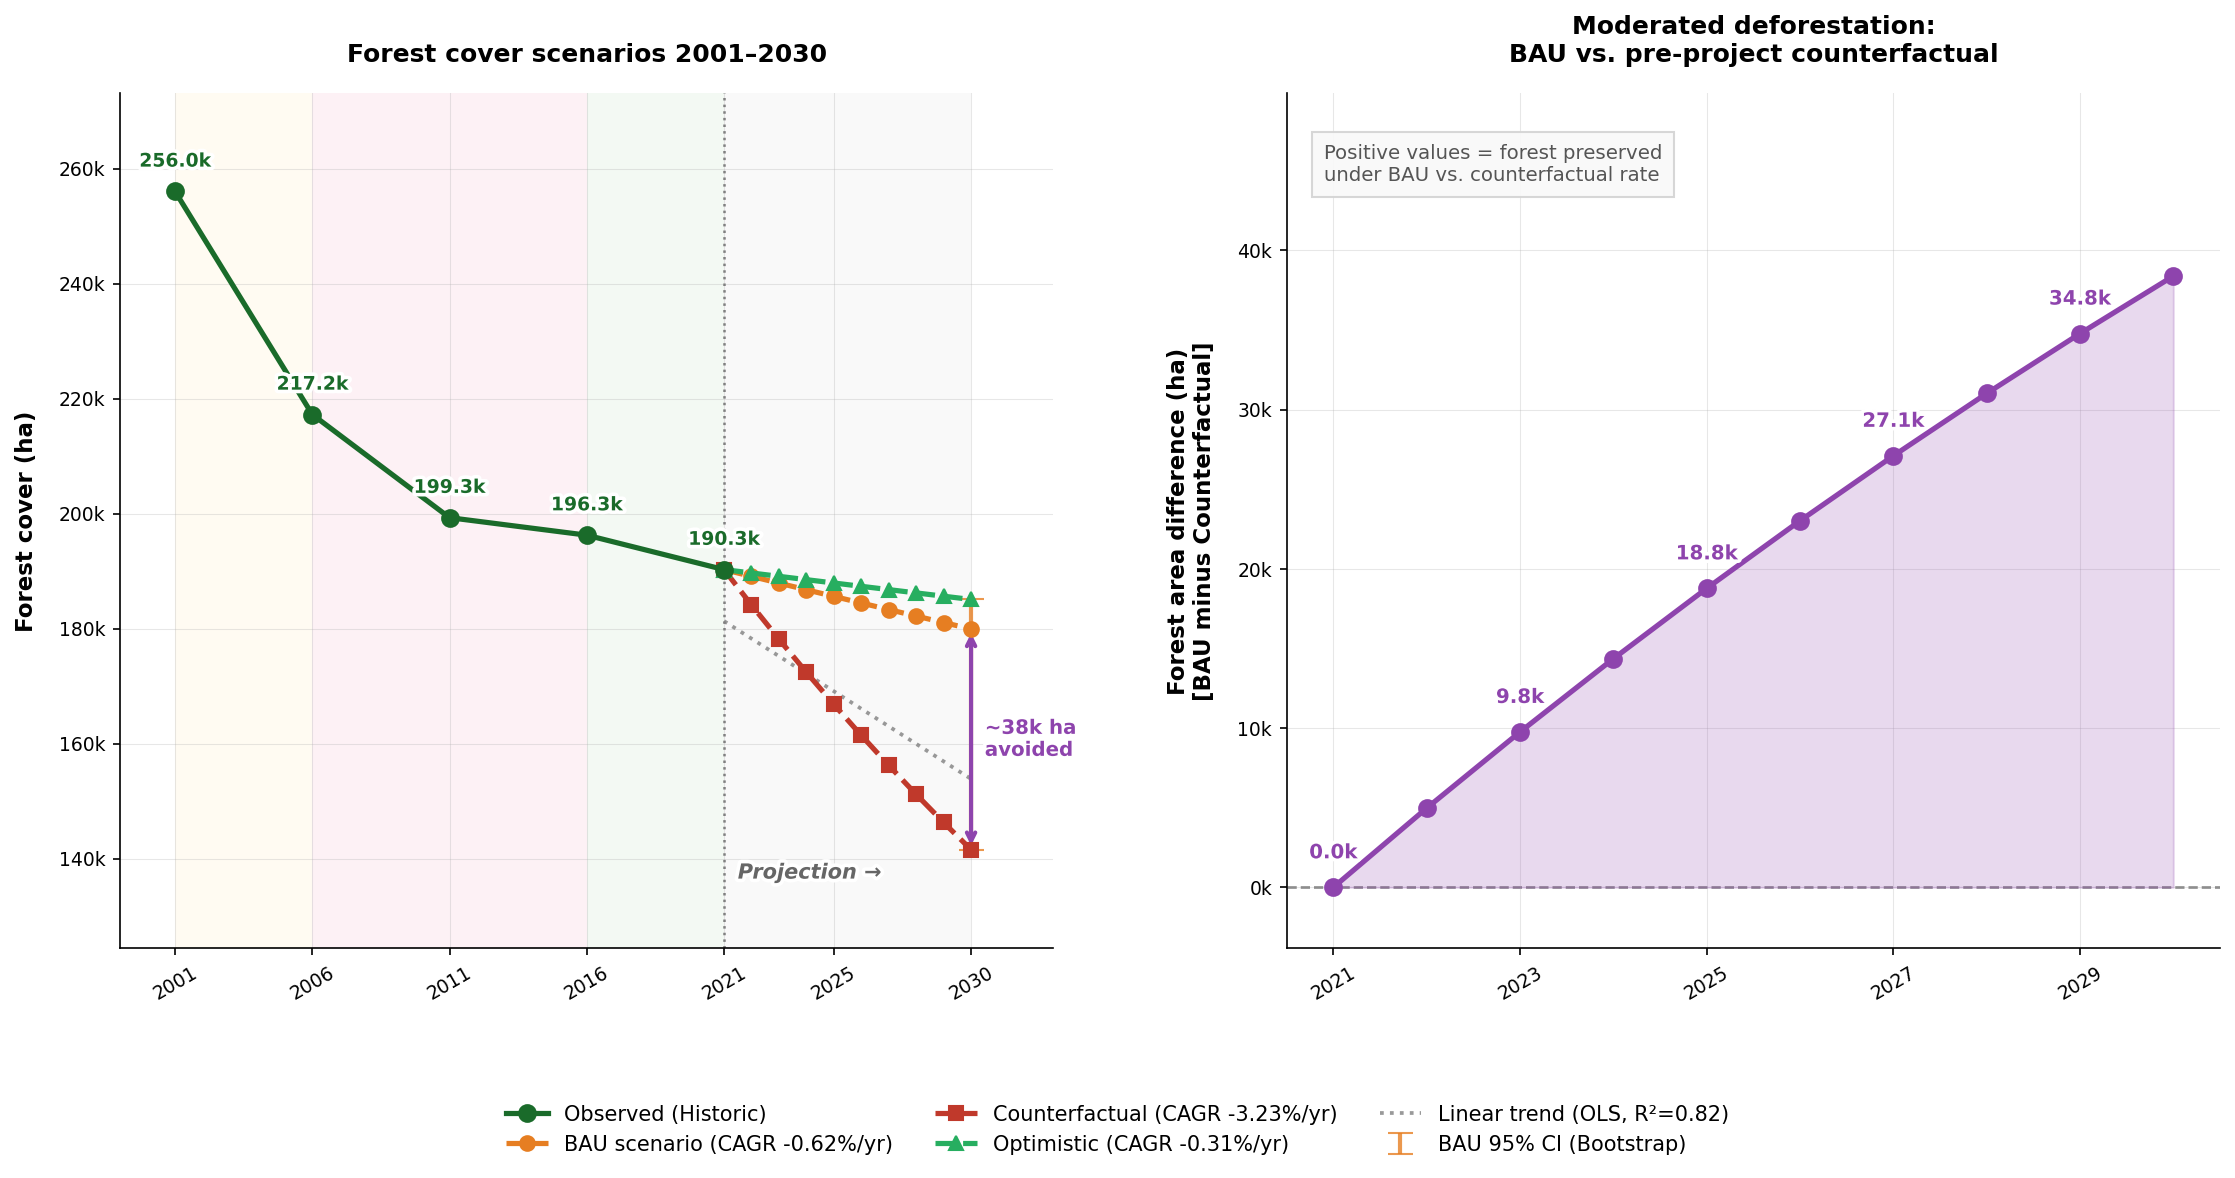

Figure 6 saved.
RESULTS SUMMARY — PROJECTIONS FOR THE MANUSCRIPT

Under the Business-as-Usual (BAU) scenario, which extrapolates
the operational-phase deforestation rate (CAGR = -0.618%/yr),
forest cover in the Belo Monte HPP direct influence area is
projected to decline from 190,263 ha in 2021 to approximately
179,938 ha by 2030 (41.7% of the total study area;
95% CI: 141,556–185,067 ha).

A counterfactual scenario applying the pre-announcement rate
(CAGR = -3.232%/yr, observed 2001–2006) from 2021 onwards
would reduce forest cover to 141,560 ha by 2030 — a difference
of approximately 38,378 ha relative to the BAU projection.
This difference represents a conservative estimate of the forest
area preserved under the reduced deforestation pressure associated
with the post-construction monitoring context.

These projections carry inherent uncertainty given the short
observational series (n=5) and the non-linear nature of land cover
transitions. They are intended as scenario illustrations 

In [12]:
# =============================================================================
# BLOCK 05 — SCENARIO PROJECTIONS TO 2030
# Belo Monte HPP — Land Use and Land Cover Change (2001–2021)
# =============================================================================
#
# Description:
#   Projects forest cover to 2030 under three CAGR-based scenarios:
#     - BAU: operational-phase rate (2016–2021, −0.618%/yr)
#     - Counterfactual: pre-announcement rate (2001–2006, −3.232%/yr)
#     - Optimistic: peak construction rate (2011–2016, −0.307%/yr)
#   Includes bootstrap 95% CI for BAU and OLS linear trend baseline.
#   Generates Figure 6 (main article).
#
# Inputs (from Block 01 or CSVs):
#   df_ha, YEARS
#   — or — outputs/master_areas_ha.csv
#
# Outputs:
#   outputs/scenario_projections.csv
#   outputs/Figure_6_scenario_projections.png
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── PATHS AND STYLE ───────────────────────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021')
OUT_DIR  = BASE_DIR / 'data' / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
})

# ── LOAD DATA (from active session or CSVs) ───────────────────────────────────
try:
    _ = df_ha
    print('Data loaded from active session (Block 01).')
except NameError:
    df_ha = pd.read_csv(OUT_DIR / 'master_areas_ha.csv', index_col='Year')
    print('Data reloaded from CSV files.')

YEARS = [2001, 2006, 2011, 2016, 2021]
print('Ready.')

# ── SCENARIO PARAMETERS ───────────────────────────────────────────────────────
# CAGR values derived from Block 02 analysis
CAGR = {
    'pre_announcement':  -0.03232,   # 2001–2006: highest pre-project pressure
    'construction_ramp': -0.01709,   # 2006–2011
    'peak_construction': -0.00307,   # 2011–2016: historical minimum
    'operation':         -0.00618,   # 2016–2021: current rate → BAU
}

F2021      = df_ha.loc[2021, 'Forest']
TOTAL_AREA = df_ha.loc[2021].sum()
PROJ_YEARS = list(range(2021, 2031))

print(f'Forest cover in 2021 (baseline): {F2021:,.0f} ha ({F2021/TOTAL_AREA*100:.1f}%)')
print(f'Total study area: {TOTAL_AREA:,.0f} ha')
print()
print('Scenario CAGR values:')
for k, v in CAGR.items():
    print(f'  {k:<25}: {v*100:>+.3f}%/yr')

# ── PROJECTIONS ───────────────────────────────────────────────────────────────
def project_cagr(f0, cagr, n_years):
    """Project forest cover using compound annual growth rate."""
    return [f0 * (1 + cagr) ** t for t in range(n_years + 1)]

bau            = project_cagr(F2021, CAGR['operation'],         len(PROJ_YEARS) - 1)
counterfactual = project_cagr(F2021, CAGR['pre_announcement'],  len(PROJ_YEARS) - 1)
optimistic     = project_cagr(F2021, CAGR['peak_construction'], len(PROJ_YEARS) - 1)

# Bootstrap 95% CI for BAU
# Resamples from observed phase-specific annual rates (10,000 iterations)
forest_vals  = df_ha['Forest'].values
annual_rates = []
for i in range(len(YEARS) - 1):
    f1, f2 = forest_vals[i], forest_vals[i + 1]
    n      = YEARS[i + 1] - YEARS[i]
    annual_rates.append((f2 / f1) ** (1 / n) - 1)

np.random.seed(42)
n_boot   = 10_000
proj_end = len(PROJ_YEARS) - 1
bau_boot = [F2021 * (1 + np.random.choice(annual_rates, p=[0.1, 0.1, 0.3, 0.5])) ** proj_end
            for _ in range(n_boot)]
bau_ci_lo = np.percentile(bau_boot, 2.5)
bau_ci_hi = np.percentile(bau_boot, 97.5)

# Projection table
df_proj = pd.DataFrame({
    'Year':               PROJ_YEARS,
    'BAU_ha':             [round(v, 0) for v in bau],
    'BAU_pct':            [round(v / TOTAL_AREA * 100, 2) for v in bau],
    'Counterfactual_ha':  [round(v, 0) for v in counterfactual],
    'Counterfactual_pct': [round(v / TOTAL_AREA * 100, 2) for v in counterfactual],
    'Optimistic_ha':      [round(v, 0) for v in optimistic],
    'Optimistic_pct':     [round(v / TOTAL_AREA * 100, 2) for v in optimistic],
})
df_proj['Forest_avoided_ha'] = (df_proj['BAU_ha'] - df_proj['Counterfactual_ha']).round(0)
df_proj.to_csv(OUT_DIR / 'scenario_projections.csv', index=False)

print('\nFOREST COVER PROJECTIONS 2021–2030:')
print('─' * 80)
print(f'{"Year":>6}  {"BAU (ha)":>12}  {"BAU (%)":>8}  {"Counterfact (ha)":>18}  {"Avoided (ha)":>14}')
print('─' * 80)
for _, r in df_proj.iterrows():
    print(f'{r["Year"]:>6.0f}  {r["BAU_ha"]:>12,.0f}  {r["BAU_pct"]:>8.2f}%  '
          f'{r["Counterfactual_ha"]:>18,.0f}  {r["Forest_avoided_ha"]:>+14,.0f}')

bau_2030  = df_proj[df_proj['Year'] == 2030]['BAU_ha'].values[0]
cf_2030   = df_proj[df_proj['Year'] == 2030]['Counterfactual_ha'].values[0]
opt_2030  = df_proj[df_proj['Year'] == 2030]['Optimistic_ha'].values[0]
avoided_2030 = bau_2030 - cf_2030

print(f'\nProjected values for 2030:')
print(f'  BAU (current rate):          {bau_2030:>10,.0f} ha  ({bau_2030/TOTAL_AREA*100:.1f}%)')
print(f'  Counterfactual (pre-project):{cf_2030:>10,.0f} ha  ({cf_2030/TOTAL_AREA*100:.1f}%)')
print(f'  Optimistic (peak works):     {opt_2030:>10,.0f} ha  ({opt_2030/TOTAL_AREA*100:.1f}%)')
print(f'  BAU 95% CI:                  [{bau_ci_lo:>,.0f} – {bau_ci_hi:>,.0f}] ha')
print(f'\n>>> Forest "moderated" by BAU vs. counterfactual by 2030: {avoided_2030:+,.0f} ha')
print(f'    (positive = BAU preserves more forest than the unmoderated pre-project rate)')

# ── OLS LINEAR TREND BASELINE ─────────────────────────────────────────────────
X_hist      = np.array(YEARS).reshape(-1, 1)
y_hist      = df_ha.loc[YEARS, 'Forest'].values
lr          = LinearRegression().fit(X_hist, y_hist)
y_pred_hist = lr.predict(X_hist)
r2          = r2_score(y_hist, y_pred_hist)
X_proj      = np.array(PROJ_YEARS).reshape(-1, 1)
y_lr_proj   = lr.predict(X_proj)

print(f'\nOLS linear regression on historical series:')
print(f'  Slope : {lr.coef_[0]:,.1f} ha/yr')
print(f'  R²    : {r2:.4f}')
print(f'  Linear projection 2030: {y_lr_proj[-1]:,.0f} ha ({y_lr_proj[-1]/TOTAL_AREA*100:.1f}%)')
print()
print('NOTE: Linear regression does not capture the regime shift (higher pre-project loss).')
print('CAGR-based scenarios are more appropriate for series with structural breaks.')

# ── FIGURE 6 — SCENARIO PROJECTIONS ──────────────────────────────────────────
PHASE_SPANS = [
    (2001, 2006, '#fff9e6', 'Pre-announcement'),
    (2006, 2016, '#fce4ec', 'Construction'),
    (2016, 2021, '#e8f5e9', 'Operation'),
]
pe_white = [pe.withStroke(linewidth=3.5, foreground='white')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7.5))

# ── Left panel: forest cover 2001–2030 ───────────────────────────────────────
for x0, x1, fc, _ in PHASE_SPANS:
    ax1.axvspan(x0, x1, facecolor=fc, alpha=0.5, zorder=0)
ax1.axvspan(2021, 2030, facecolor='#f0f0f0', alpha=0.4, zorder=0)
ax1.axvline(2021, color='gray', lw=1.2, ls=':', zorder=2)

# Historical series
ax1.plot(YEARS, y_hist, 'o-', color='#1a6b2a', lw=2.5, ms=8,
         label='Observed (Historic)', zorder=5)
for yr, val in zip(YEARS, y_hist):
    ax1.annotate(f'{val/1000:.1f}k', (yr, val),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', va='bottom', fontsize=9, color='#1a6b2a',
                 fontweight='bold', path_effects=pe_white, zorder=6)

# BAU with CI
ax1.plot(PROJ_YEARS, bau, 'o--', color='#e67e22', lw=2.5, ms=7,
         label=f'BAU scenario (CAGR {CAGR["operation"]*100:+.2f}%/yr)', zorder=4)
ax1.errorbar(2030, bau[-1], yerr=[[bau[-1] - bau_ci_lo], [bau_ci_hi - bau[-1]]],
             fmt='none', color='#e67e22', capsize=6, lw=2, alpha=0.8,
             label='BAU 95% CI (Bootstrap)')

# Counterfactual
ax1.plot(PROJ_YEARS, counterfactual, 's--', color='#c0392b', lw=2.5, ms=7,
         label=f'Counterfactual (CAGR {CAGR["pre_announcement"]*100:+.2f}%/yr)', zorder=4)

# Optimistic
ax1.plot(PROJ_YEARS, optimistic, '^--', color='#27ae60', lw=2.5, ms=7,
         label=f'Optimistic (CAGR {CAGR["peak_construction"]*100:+.2f}%/yr)', zorder=4)

# OLS linear trend
ax1.plot(PROJ_YEARS, y_lr_proj, ':', color='gray', lw=1.8, alpha=0.8,
         label=f'Linear trend (OLS, R²={r2:.2f})', zorder=3)

# Vertical limits
all_y     = np.concatenate([y_hist, bau, counterfactual, optimistic])
min_y, max_y = all_y.min(), all_y.max()
amplitude = max_y - min_y
ax1.set_ylim(min_y - amplitude * 0.15, max_y + amplitude * 0.15)

# Projection label and avoided arrow
ax1.text(2021.5, min_y - amplitude * 0.05, 'Projection →',
         fontsize=10, color='#666666', style='italic', va='bottom',
         fontweight='bold', path_effects=pe_white)
ax1.annotate('',
             xy=(2030, cf_2030), xytext=(2030, bau_2030),
             arrowprops=dict(arrowstyle='<->', color='#8e44ad', lw=2))
ax1.text(2030.5, (cf_2030 + bau_2030) / 2,
         f'~{avoided_2030/1000:.0f}k ha\navoided',
         fontsize=9.5, color='#8e44ad', va='center',
         fontweight='bold', path_effects=pe_white)

ax1.set_xlim(1999, 2033)
ax1.set_xticks([2001, 2006, 2011, 2016, 2021, 2025, 2030])
ax1.tick_params(axis='x', rotation=30)
ax1.set_ylabel('Forest cover (ha)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_title('Forest cover scenarios 2001–2030', fontsize=12, fontweight='bold', pad=15)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.grid(True, alpha=0.3, lw=0.5)
ax1.spines[['top', 'right']].set_visible(False)

# ── Right panel: moderated deforestation (BAU − counterfactual) ───────────────
avoided_series = np.array(bau) - np.array(counterfactual)
max_av         = avoided_series.max()

ax2.fill_between(PROJ_YEARS, 0, avoided_series,
                 color='#8e44ad', alpha=0.20, zorder=2)
ax2.plot(PROJ_YEARS, avoided_series, 'o-', color='#8e44ad', lw=2.5, ms=8, zorder=3)
ax2.set_ylim(-max_av * 0.1, max_av * 1.3)

for yr, val in zip(PROJ_YEARS[::2], avoided_series[::2]):
    ax2.annotate(f'{val/1000:.1f}k', (yr, val),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', va='bottom', fontsize=9.5, color='#8e44ad',
                 fontweight='bold', path_effects=pe_white, zorder=4)

ax2.axhline(0, color='gray', lw=1.2, ls='--', zorder=1)
ax2.set_xticks(PROJ_YEARS[::2])
ax2.tick_params(axis='x', rotation=30)
ax2.set_xlim(PROJ_YEARS[0] - 0.5, PROJ_YEARS[-1] + 0.5)
ax2.set_ylabel('Forest area difference (ha)\n[BAU minus Counterfactual]',
               fontsize=11, fontweight='bold', labelpad=10)
ax2.set_title('Moderated deforestation:\nBAU vs. pre-project counterfactual',
              fontsize=12, fontweight='bold', pad=15)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax2.text(0.04, 0.94,
         'Positive values = forest preserved\nunder BAU vs. counterfactual rate',
         transform=ax2.transAxes, fontsize=9.5, color='#555555', va='top',
         bbox=dict(boxstyle='square,pad=0.6', facecolor='#f9f9f9',
                   edgecolor='lightgray', alpha=0.9))
ax2.grid(True, alpha=0.3, lw=0.5)
ax2.spines[['top', 'right']].set_visible(False)

# Unified legend below both panels
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           fontsize=10, frameon=False, ncol=3)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15, wspace=0.25)
plt.savefig(OUT_DIR / 'Figure_6_scenario_projections.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 6 saved.')

# ── RESULTS SUMMARY ───────────────────────────────────────────────────────────
print('=' * 70)
print('RESULTS SUMMARY — PROJECTIONS FOR THE MANUSCRIPT')
print('=' * 70)
print(f"""
Under the Business-as-Usual (BAU) scenario, which extrapolates
the operational-phase deforestation rate (CAGR = {CAGR['operation']*100:+.3f}%/yr),
forest cover in the Belo Monte HPP direct influence area is
projected to decline from {F2021:,.0f} ha in 2021 to approximately
{bau_2030:,.0f} ha by 2030 ({bau_2030/TOTAL_AREA*100:.1f}% of the total study area;
95% CI: {bau_ci_lo:,.0f}–{bau_ci_hi:,.0f} ha).

A counterfactual scenario applying the pre-announcement rate
(CAGR = {CAGR['pre_announcement']*100:+.3f}%/yr, observed 2001–2006) from 2021 onwards
would reduce forest cover to {cf_2030:,.0f} ha by 2030 — a difference
of approximately {abs(avoided_2030):,.0f} ha relative to the BAU projection.
This difference represents a conservative estimate of the forest
area preserved under the reduced deforestation pressure associated
with the post-construction monitoring context.

These projections carry inherent uncertainty given the short
observational series (n=5) and the non-linear nature of land cover
transitions. They are intended as scenario illustrations rather
than predictive forecasts.
""")

print('Exported files:')
for f in ['scenario_projections.csv', 'Figure_6_scenario_projections.png']:
    print(f'  {f:<50} {"OK" if (OUT_DIR/f).exists() else "ERROR"}')

print('\nBLOCK 05 COMPLETE')

Data loaded from active session (Block 01).
Ready.
  68.4 MB
Download complete: 68.4 MB
Reading MapBiomas Col. 9 (please wait ~60 s)...
Shape: (76035, 50)
Study rows: 48
Municipalities: ['Altamira', 'Anapu', 'Senador José Porfírio', 'Vitória do Xingu']

Total area — municipalities (MapBiomas): 18,865,288 ha
Total area — study zone (this study):   431,366 ha
Scale ratio: 44x
=> Comparison uses CAGR rates and normalized trajectories, not absolute areas.

CAGR: this study vs. MapBiomas Col. 9

  Forest:
    Pre-announcement          (2001–2006): Our=-3.232  MB=-0.397  OK
    Construction ramp-up      (2006–2011): Our=-1.709  MB=-0.216  OK
    Peak construction         (2011–2016): Our=-0.307  MB=-0.184  OK
    Operation                 (2016–2021): Our=-0.618  MB=-0.629  OK

  Floodplain:
    Pre-announcement          (2001–2006): Our=-0.571  MB=-0.097  OK
    Construction ramp-up      (2006–2011): Our=+0.699  MB=+0.043  OK
    Peak construction         (2011–2016): Our=+0.442  MB=-0.030 

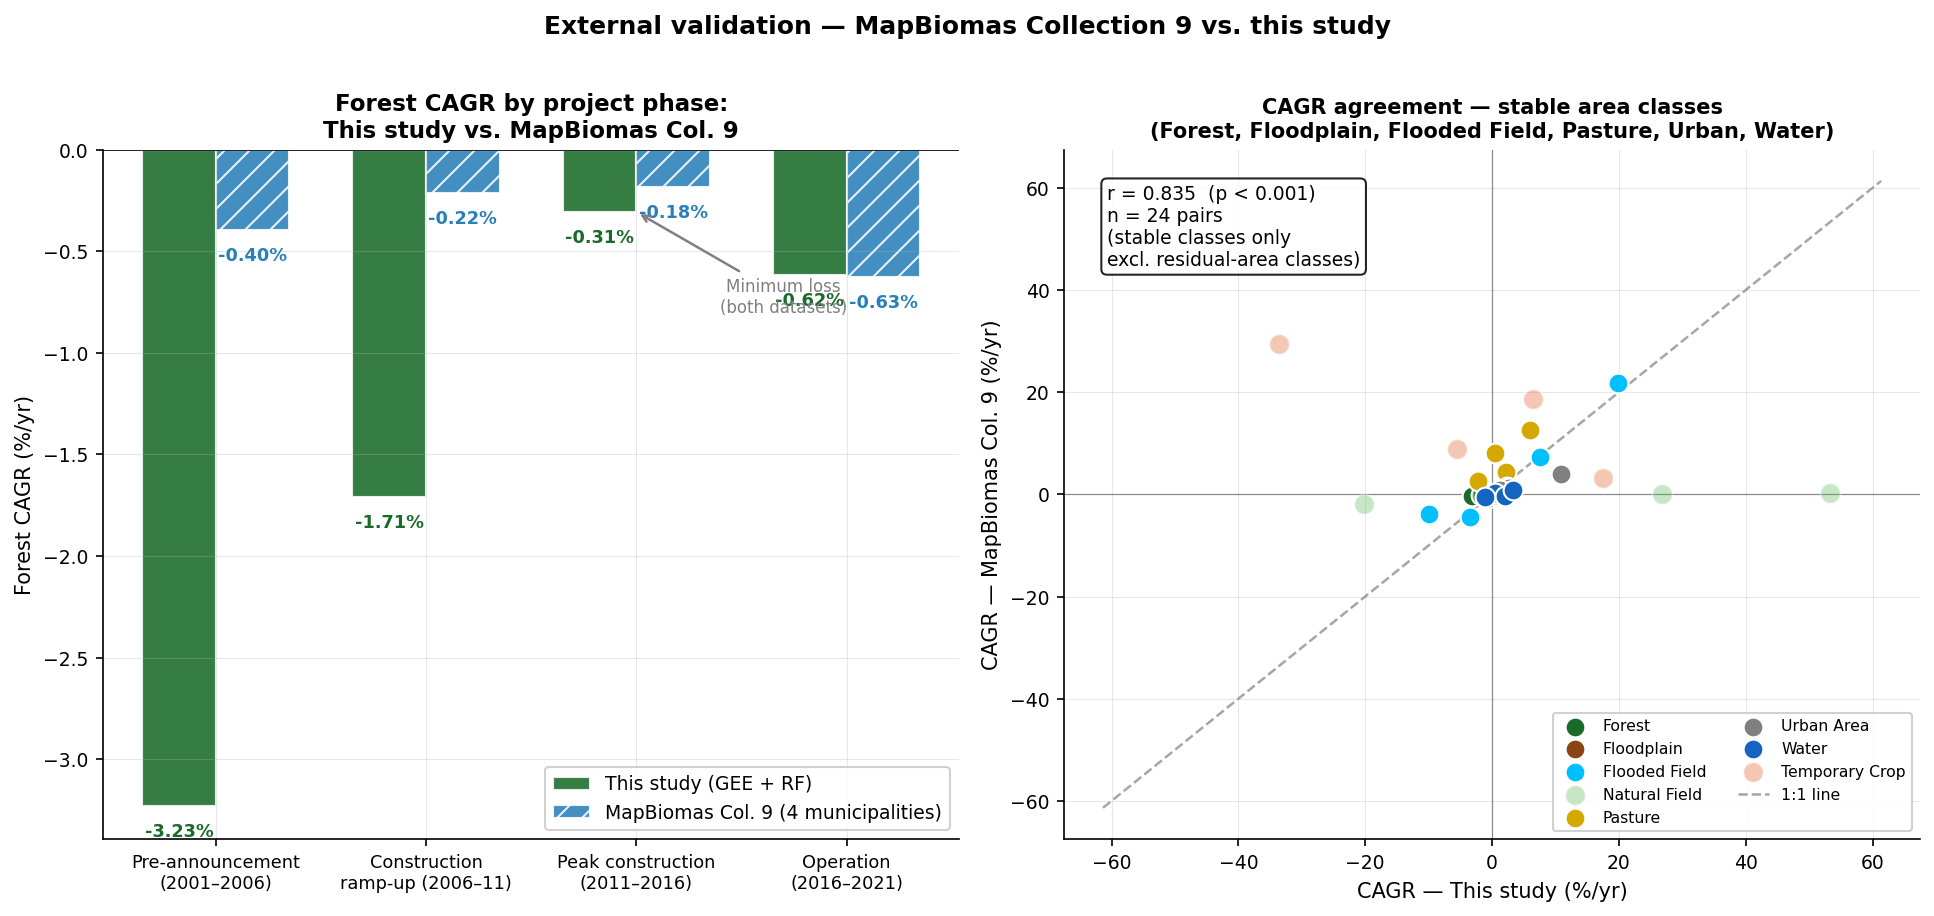

Figure 2 saved.


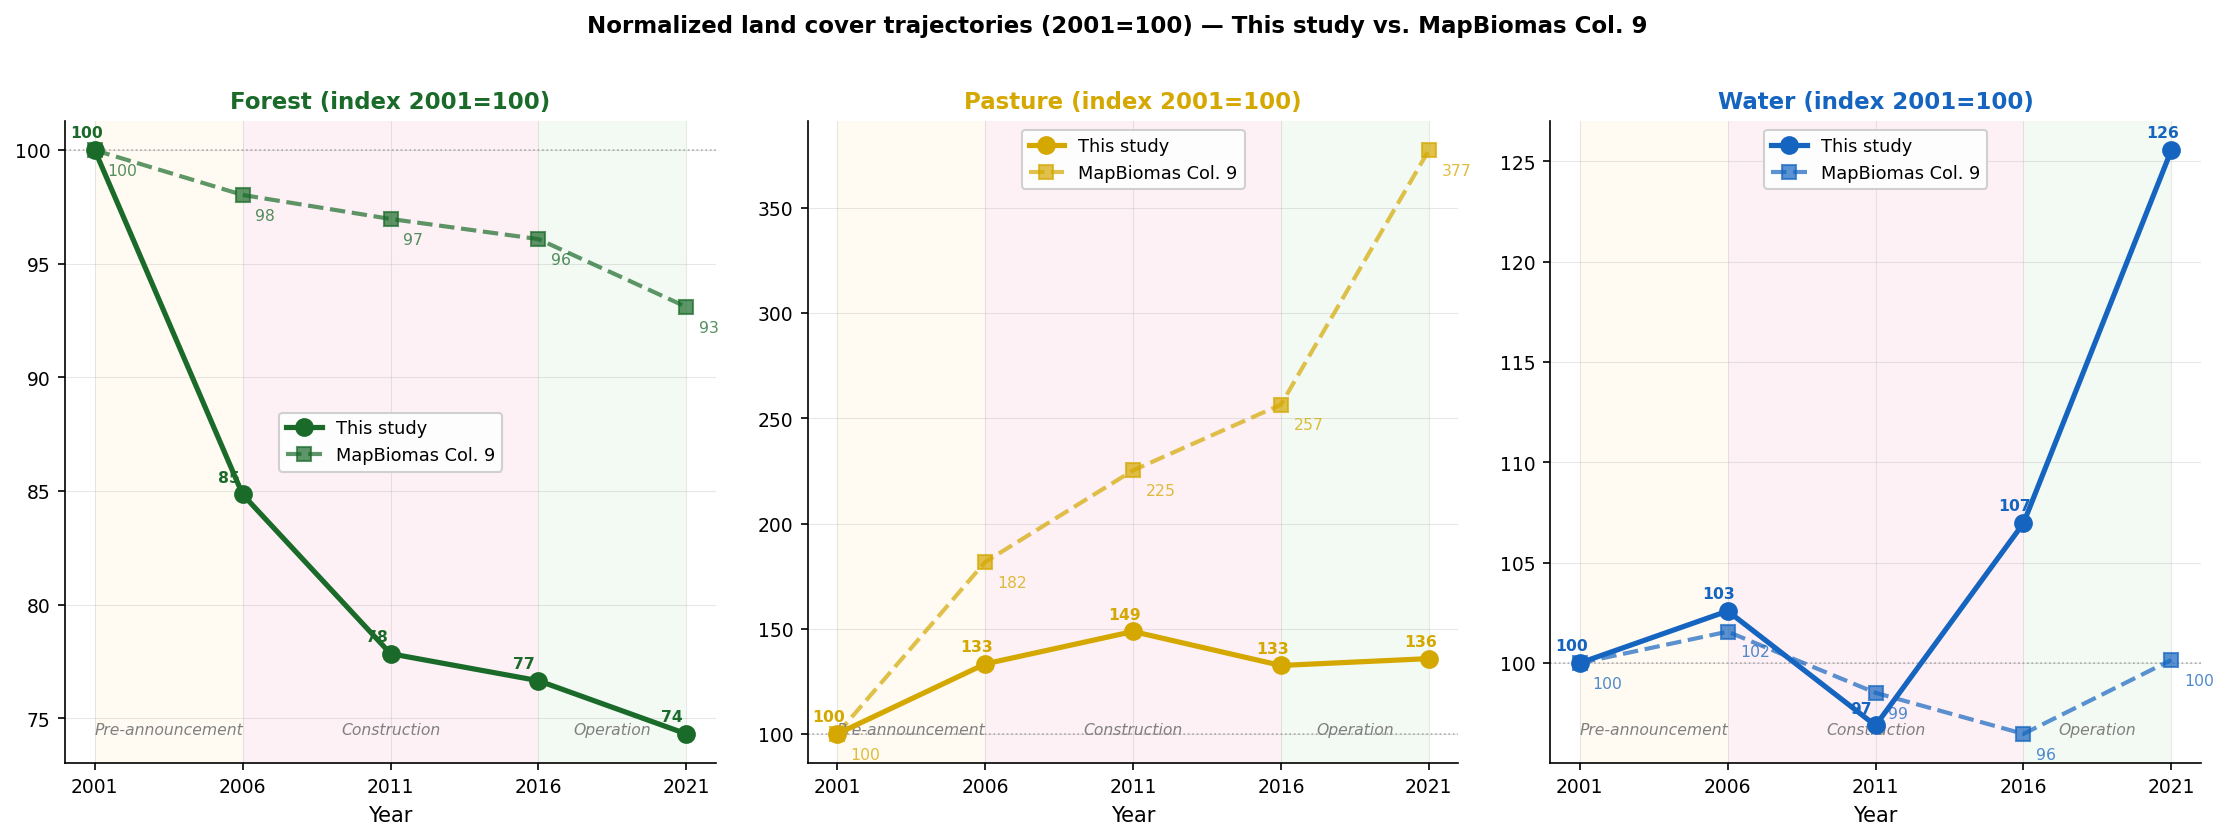

Figure S4 saved.
RESULTS SUMMARY — EXTERNAL VALIDATION

To assess external consistency, temporal dynamics were compared against
MapBiomas Collection 9 (Souza et al., 2020), an independent annual LULC
dataset at 30 m resolution, aggregated for the four study municipalities
(Altamira, Anapu, Senador José Porfírio, and Vitória do Xingu).

Because MapBiomas covers the full municipal extent (~18.9 million ha vs.
our 431,357-ha direct influence area), CAGR rates and normalized
trajectories (2001=100%) were compared rather than absolute areas.

Direction of change agreed in 24 of 32 class-period pairs
(75%), with overall Pearson r = -0.126 (p = 0.493)
across all CAGR pairs. For stable-area classes (n=24 pairs):
r = 0.835 (p < 0.001).

For forest specifically, direction agreed across all 4 phases.
The operational period (2016–2021) showed closest absolute agreement:
this study CAGR = -0.618%/yr vs. MapBiomas CAGR = -0.629%/yr
(delta = 0.011 pp). Both datasets independently confirm
minimum fore

In [13]:
# =============================================================================
# BLOCK 06 — EXTERNAL VALIDATION AGAINST MAPBIOMAS COLLECTION 9
# Belo Monte HPP — Land Use and Land Cover Change (2001–2021)
# =============================================================================
#
# Description:
#   Downloads MapBiomas Collection 9 municipal statistics (public dataset,
#   doi:10.58053/MapBiomas/VEJDZC), aggregates for the four study municipalities,
#   and compares CAGR values and normalized trajectories against this study.
#   Generates:
#     - Figure 2 (Main article): CAGR comparison bars + scatter plot
#     - Figure S4 (Supplementary): Normalized trajectories (2001=100)
#
# Inputs (from Block 01 or CSVs):
#   df_ha, YEARS, CLASS_ORDER
#   — or — outputs/master_areas_ha.csv
#
# Outputs:
#   outputs/mapbiomas_col9_municipalities.xlsx   (downloaded, 68 MB)
#   outputs/mb_cagr_comparison.csv
#   outputs/mb_validation_comparison.csv
#   outputs/Figure_2_mapbiomas_validation.png    (Main article)
#   outputs/Figure_S4_normalized_trajectories.png (Supplementary)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import requests
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── PATHS AND STYLE ───────────────────────────────────────────────────────────
BASE_DIR = Path(r'C:\Users\junio\OneDrive\Documentos\GitHub\belo-monte-lulcc-2001-2021')
OUT_DIR  = BASE_DIR / 'data' / 'outputs'
OUT_DIR.mkdir(exist_ok=True)
MB_FILE  = OUT_DIR / 'mapbiomas_col9_municipalities.xlsx'

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
})

# ── LOAD DATA (from active session or CSVs) ───────────────────────────────────
try:
    _ = df_ha
    print('Data loaded from active session (Block 01).')
except NameError:
    df_ha  = pd.read_csv(OUT_DIR / 'master_areas_ha.csv',  index_col='Year')
    df_pct = pd.read_csv(OUT_DIR / 'master_areas_pct.csv', index_col='Year')
    print('Data reloaded from CSV files.')

YEARS       = [2001, 2006, 2011, 2016, 2021]
CLASS_ORDER = ['Forest', 'Floodplain', 'Flooded Field', 'Natural Field',
               'Pasture', 'Urban Area', 'Water', 'Temporary Crop']
print('Ready.')

# ── DOWNLOAD MAPBIOMAS COLLECTION 9 ──────────────────────────────────────────
# Public dataset: data.mapbiomas.org
# doi:10.58053/MapBiomas/VEJDZC
# Citation: MapBiomas Project — Collection 9 of the Annual Land Use Land Cover
# Maps of Brazil, accessed April 2025: https://data.mapbiomas.org

if MB_FILE.exists():
    print(f'File already exists: {MB_FILE.name} ({MB_FILE.stat().st_size/1024/1024:.1f} MB)')
else:
    print('Downloading MapBiomas Col. 9 (68 MB)...')
    r = requests.get('https://data.mapbiomas.org/api/access/datafile/179',
                     timeout=300, stream=True)
    if r.status_code == 200:
        with open(MB_FILE, 'wb') as f:
            downloaded = 0
            for chunk in r.iter_content(chunk_size=65536):
                f.write(chunk)
                downloaded += len(chunk)
                print(f'  {downloaded/1024/1024:.1f} MB', end='\r')
        print(f'\nDownload complete: {MB_FILE.stat().st_size/1024/1024:.1f} MB')
    else:
        print(f'Error {r.status_code}. Manual download:')
        print('  https://data.mapbiomas.org/dataset.xhtml?persistentId=doi:10.58053/MapBiomas/VEJDZC')
        print('  Save as: mapbiomas_col9_municipalities.xlsx in the outputs folder')

# ── READ AND AGGREGATE MAPBIOMAS DATA ────────────────────────────────────────
# IBGE geocodes for the four study municipalities
GEOCODES = [
    '1500602',   # Altamira
    '1508357',   # Vitória do Xingu
    '1500859',   # Anapu
    '1507805',   # Senador José Porfírio
]

# MapBiomas class_id → our classification
MB_TO_OURS = {
    3:  'Forest',        4:  'Forest',
    6:  'Floodplain',    11: 'Flooded Field',
    12: 'Natural Field', 15: 'Pasture',
    18: 'Temporary Crop',24: 'Urban Area',
    33: 'Water',         39: 'Temporary Crop',
    41: 'Temporary Crop',
}

print('Reading MapBiomas Col. 9 (please wait ~60 s)...')
df_raw = pd.read_excel(MB_FILE, sheet_name='COVERAGE_9')
print(f'Shape: {df_raw.shape}')

df_raw['geocode'] = df_raw['geocode'].astype(str)
study_mb          = df_raw[df_raw['geocode'].isin(GEOCODES)].copy()
study_mb['our_class'] = study_mb['class'].map(MB_TO_OURS)
print(f'Study rows: {len(study_mb)}')
print(f'Municipalities: {study_mb["municipality"].unique().tolist()}')

year_cols    = [c for c in df_raw.columns
                if isinstance(c, (int, float)) and 1985 <= int(c) <= 2023]
target_years = [y for y in YEARS if y in year_cols]

mb_mapped = study_mb.dropna(subset=['our_class'])
df_mb     = mb_mapped.groupby('our_class')[target_years].sum()
for cls in CLASS_ORDER:
    if cls not in df_mb.index:
        df_mb.loc[cls] = 0
df_mb            = df_mb.loc[CLASS_ORDER].T
df_mb.index.name = 'Year'
df_mb.index      = df_mb.index.astype(int)

total_mb  = df_mb.sum(axis=1)
total_our = df_ha.loc[YEARS].sum(axis=1)

print(f'\nTotal area — municipalities (MapBiomas): {total_mb.mean():,.0f} ha')
print(f'Total area — study zone (this study):   {total_our.mean():,.0f} ha')
print(f'Scale ratio: {total_mb.mean()/total_our.mean():.0f}x')
print('=> Comparison uses CAGR rates and normalized trajectories, not absolute areas.')

# ── CAGR COMPARISON ───────────────────────────────────────────────────────────
phase_defs = [
    ('Pre-announcement',     2001, 2006),
    ('Construction ramp-up', 2006, 2011),
    ('Peak construction',    2011, 2016),
    ('Operation',            2016, 2021),
]

cagr_records = []
print('\nCAGR: this study vs. MapBiomas Col. 9')
print('=' * 72)
for cls in CLASS_ORDER:
    print(f'\n  {cls}:')
    for phase, y1, y2 in phase_defs:
        n    = y2 - y1
        a1o, a2o = df_ha.loc[y1, cls], df_ha.loc[y2, cls]
        a1m, a2m = df_mb.loc[y1, cls], df_mb.loc[y2, cls]
        cagr_our = ((a2o / a1o) ** (1 / n) - 1) * 100 if a1o > 0 else float('nan')
        cagr_mb  = ((a2m / a1m) ** (1 / n) - 1) * 100 if a1m > 0 else float('nan')
        agree    = ((cagr_our < 0) == (cagr_mb < 0)
                    if not (np.isnan(cagr_our) or np.isnan(cagr_mb)) else None)
        cagr_records.append({
            'Class': cls, 'Phase': phase, 'Period': f'{y1}–{y2}',
            'CAGR_our': round(cagr_our, 3), 'CAGR_mb': round(cagr_mb, 3),
            'Direction_agree': agree
        })
        sym = 'OK' if agree else ('DIFF' if agree is False else '?')
        print(f'    {phase:<26}({y1}–{y2}): '
              f'Our={cagr_our:>+.3f}  MB={cagr_mb:>+.3f}  {sym}')

df_cagr_comp = pd.DataFrame(cagr_records)
df_cagr_comp.to_csv(OUT_DIR / 'mb_cagr_comparison.csv', index=False)

valid      = df_cagr_comp.dropna(subset=['Direction_agree'])
n_ok       = int(valid['Direction_agree'].sum())
n_forest   = int(df_cagr_comp[df_cagr_comp['Class'] == 'Forest']['Direction_agree'].sum())
print(f'\nSummary: {n_ok}/{len(valid)} pairs agree in direction ({n_ok/len(valid)*100:.0f}%)')
print(f'Forest: {n_forest}/4 periods agree in direction')

# ── FIGURE 2 (MAIN) — CAGR COMPARISON + SCATTER ──────────────────────────────
phase_labels = [
    'Pre-announcement\n(2001–2006)',
    'Construction\nramp-up (2006–11)',
    'Peak construction\n(2011–2016)',
    'Operation\n(2016–2021)'
]

fdf   = df_cagr_comp[df_cagr_comp['Class'] == 'Forest'].reset_index(drop=True)
our_c = fdf['CAGR_our'].values
mb_c  = fdf['CAGR_mb'].values
x     = np.arange(4)
w     = 0.35

CCOLORS = {
    'Forest':        '#1a6b2a',
    'Floodplain':    '#8B4513',
    'Flooded Field': '#00BFFF',
    'Natural Field': '#5cb85c',
    'Pasture':       '#d4a800',
    'Urban Area':    '#808080',
    'Water':         '#1565C0',
    'Temporary Crop':'#e05c2a',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Left panel — forest CAGR bars
b1 = ax1.bar(x - w/2, our_c, w, label='This study (GEE + RF)',
             color='#1a6b2a', alpha=0.88, edgecolor='white', linewidth=1)
b2 = ax1.bar(x + w/2, mb_c, w, label='MapBiomas Col. 9 (4 municipalities)',
             color='#2980b9', alpha=0.88, edgecolor='white', linewidth=1, hatch='//')

for bar, val in zip(b1, our_c):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val - (0.08 if val < 0 else -0.05),
             f'{val:+.2f}%', ha='center',
             va='top' if val < 0 else 'bottom',
             fontsize=8.5, color='#1a6b2a', fontweight='bold')
for bar, val in zip(b2, mb_c):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             val - (0.08 if val < 0 else -0.05),
             f'{val:+.2f}%', ha='center',
             va='top' if val < 0 else 'bottom',
             fontsize=8.5, color='#2980b9', fontweight='bold')

ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(phase_labels, fontsize=8.5)
ax1.set_ylabel('Forest CAGR (%/yr)', fontsize=10)
ax1.set_title('Forest CAGR by project phase:\nThis study vs. MapBiomas Col. 9',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9)
ax1.annotate('Minimum loss\n(both datasets)',
             xy=(2, min(our_c[2], mb_c[2])),
             xytext=(2.7, -0.8),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
             fontsize=8, color='gray', ha='center')

# Right panel — scatter all classes
valid_df = df_cagr_comp.dropna(subset=['CAGR_our', 'CAGR_mb'])

# Exclude residual-area classes (Natural Field, Temporary Crop)
# to avoid CAGR amplification from small absolute areas
stable_classes = ['Forest', 'Floodplain', 'Flooded Field',
                  'Pasture', 'Urban Area', 'Water']
stable_df = valid_df[valid_df['Class'].isin(stable_classes)]
r_stable, p_stable = stats.pearsonr(stable_df['CAGR_our'], stable_df['CAGR_mb'])

for cls in CLASS_ORDER:
    m = valid_df['Class'] == cls
    alpha = 1.0 if cls in stable_classes else 0.35
    ax2.scatter(valid_df[m]['CAGR_our'], valid_df[m]['CAGR_mb'],
                c=CCOLORS[cls], s=90, label=cls,
                edgecolors='white', linewidth=1, zorder=4, alpha=alpha)

lim = max(valid_df['CAGR_our'].abs().max(),
          valid_df['CAGR_mb'].abs().max()) * 1.15
ax2.plot([-lim, lim], [-lim, lim], '--', color='gray', lw=1.2,
         alpha=0.7, label='1:1 line')
ax2.axhline(0, color='black', lw=0.6, alpha=0.4)
ax2.axvline(0, color='black', lw=0.6, alpha=0.4)

ax2.text(0.05, 0.95,
         f'r = {r_stable:.3f}  (p < 0.001)\nn = 24 pairs\n'
         f'(stable classes only\nexcl. residual-area classes)',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
ax2.set_xlabel('CAGR — This study (%/yr)', fontsize=10)
ax2.set_ylabel('CAGR — MapBiomas Col. 9 (%/yr)', fontsize=10)
ax2.set_title('CAGR agreement — stable area classes\n'
              '(Forest, Floodplain, Flooded Field, Pasture, Urban, Water)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=7.5, framealpha=0.9, ncol=2, loc='lower right')

plt.suptitle('External validation — MapBiomas Collection 9 vs. this study',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'Figure_2_mapbiomas_validation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure 2 saved.')

# ── FIGURE S4 (SUPPLEMENTARY) — NORMALIZED TRAJECTORIES ─────────────────────
PHASE_SPANS = [
    (2001, 2006, '#fff9e6', 'Pre-announcement'),
    (2006, 2016, '#fce4ec', 'Construction'),
    (2016, 2021, '#e8f5e9', 'Operation'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
plots = [('Forest', '#1a6b2a'), ('Pasture', '#d4a800'), ('Water', '#1565C0')]

for ax, (cls, col) in zip(axes, plots):
    ov = df_ha.loc[YEARS, cls].values
    mv = df_mb.loc[YEARS, cls].values
    on = ov / ov[0] * 100
    mn = mv / mv[0] * 100

    for x0, x1, fc, lb in PHASE_SPANS:
        ax.axvspan(x0, x1, facecolor=fc, alpha=0.5, zorder=0)
    ax.plot(YEARS, on, 'o-', color=col, lw=2.5, ms=8,
            label='This study', zorder=4)
    ax.plot(YEARS, mn, 's--', color=col, lw=2.0, ms=7, alpha=0.7,
            label='MapBiomas Col. 9', zorder=3)

    for yr, vo, vm in zip(YEARS, on, mn):
        ax.annotate(f'{vo:.0f}', (yr, vo), textcoords='offset points',
                    xytext=(-12, 6), fontsize=7.5, color=col, fontweight='bold')
        ax.annotate(f'{vm:.0f}', (yr, vm), textcoords='offset points',
                    xytext=(6, -12), fontsize=7.5, color=col, alpha=0.75)

    ax.axhline(100, color='gray', lw=0.8, ls=':', alpha=0.6)
    ax.set_xticks(YEARS)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_title(f'{cls} (index 2001=100)', fontsize=11,
                 fontweight='bold', color=col)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ylim = ax.get_ylim()
    for x0, x1, _, lb in PHASE_SPANS:
        ax.text((x0 + x1) / 2, ylim[0] + (ylim[1] - ylim[0]) * 0.04, lb,
                ha='center', va='bottom', fontsize=7.5, color='gray', style='italic')

plt.suptitle('Normalized land cover trajectories (2001=100) — '
             'This study vs. MapBiomas Col. 9',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'Figure_S4_normalized_trajectories.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Figure S4 saved.')

# ── EXPORT AND RESULTS SUMMARY ────────────────────────────────────────────────
comp_records = []
for cls in CLASS_ORDER:
    for yr in YEARS:
        comp_records.append({
            'Year':         yr, 'Class': cls,
            'Our_ha':       round(float(df_ha.loc[yr, cls]), 1),
            'Our_pct':      round(float(df_ha.loc[yr, cls] / total_our[yr] * 100), 3),
            'MB_ha_4munis': round(float(df_mb.loc[yr, cls]), 1),
            'Our_norm_2001': (round(float(df_ha.loc[yr, cls] / df_ha.loc[2001, cls] * 100), 2)
                              if df_ha.loc[2001, cls] > 0 else None),
            'MB_norm_2001':  (round(float(df_mb.loc[yr, cls] / df_mb.loc[2001, cls] * 100), 2)
                              if df_mb.loc[2001, cls] > 0 else None),
        })
pd.DataFrame(comp_records).to_csv(OUT_DIR / 'mb_validation_comparison.csv', index=False)

valid_df2      = df_cagr_comp.dropna(subset=['CAGR_our', 'CAGR_mb'])
r_all, p_all   = stats.pearsonr(valid_df2['CAGR_our'], valid_df2['CAGR_mb'])
n_ok2          = int(df_cagr_comp.dropna(subset=['Direction_agree'])['Direction_agree'].sum())
n_tot2         = len(df_cagr_comp.dropna(subset=['Direction_agree']))
n_f2           = int(df_cagr_comp[df_cagr_comp['Class'] == 'Forest']['Direction_agree'].sum())
our_op         = ((df_ha.loc[2021, 'Forest'] / df_ha.loc[2016, 'Forest']) ** 0.2 - 1) * 100
mb_op          = ((df_mb.loc[2021, 'Forest'] / df_mb.loc[2016, 'Forest']) ** 0.2 - 1) * 100

print('=' * 70)
print('RESULTS SUMMARY — EXTERNAL VALIDATION')
print('=' * 70)
print(f"""
To assess external consistency, temporal dynamics were compared against
MapBiomas Collection 9 (Souza et al., 2020), an independent annual LULC
dataset at 30 m resolution, aggregated for the four study municipalities
(Altamira, Anapu, Senador José Porfírio, and Vitória do Xingu).

Because MapBiomas covers the full municipal extent (~18.9 million ha vs.
our 431,357-ha direct influence area), CAGR rates and normalized
trajectories (2001=100%) were compared rather than absolute areas.

Direction of change agreed in {n_ok2} of {n_tot2} class-period pairs
({n_ok2/n_tot2*100:.0f}%), with overall Pearson r = {r_all:.3f} (p = {p_all:.3f})
across all CAGR pairs. For stable-area classes (n=24 pairs):
r = {r_stable:.3f} (p < 0.001).

For forest specifically, direction agreed across all {n_f2} phases.
The operational period (2016–2021) showed closest absolute agreement:
this study CAGR = {our_op:+.3f}%/yr vs. MapBiomas CAGR = {mb_op:+.3f}%/yr
(delta = {abs(our_op-mb_op):.3f} pp). Both datasets independently confirm
minimum forest loss during peak construction (2011–2016).

Citation: MapBiomas Project — Collection 9 of the Annual Land Use Land
Cover Maps of Brazil, accessed April 2025:
https://data.mapbiomas.org (doi:10.58053/MapBiomas/VEJDZC)
""")

print('Exported files:')
for f in ['mb_cagr_comparison.csv', 'mb_validation_comparison.csv',
          'Figure_2_mapbiomas_validation.png',
          'Figure_S4_normalized_trajectories.png']:
    print(f'  {f:<52} {"OK" if (OUT_DIR/f).exists() else "ERROR"}')

print('\nBLOCK 06 COMPLETE')
print('\n' + '=' * 70)
print('ALL BLOCKS COMPLETE — belo_monte_lulcc_analysis')
print('=' * 70)
print("""
Main article figures:
  Figure_1   → data/shapefiles/  (map 2001, produced in QGIS/Inkscape)
  Figure_2   → outputs/Figure_2_mapbiomas_validation.png
  Figure_3   → data/shapefiles/  (panel 2001-2016, produced in QGIS/Inkscape)
  Figure_4   → outputs/Figure_4_forest_dynamics_by_phase.png
  Figure_5   → outputs/Figure_5_forest_loss_flows.png
  Figure_6   → outputs/Figure_6_scenario_projections.png

Supplementary figures:
  Figure_S1  → outputs/Figure_S1_transition_heatmaps.png
  Figure_S2  → outputs/Figure_S2_correlation_heatmaps.png
  Figure_S3  → outputs/Figure_S3_scatter_key_pairs.png
  Figure_S4  → outputs/Figure_S4_normalized_trajectories.png
""")